In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/dataset_pump.csv")
df

,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag,Failure_Flag
0,2,104.04,2.495,191.84,9.671,1986,0.0,0,0
1,2,100.65,2.641,200.48,9.465,2011,20.2,0,0
2,2,101.22,2.794,209.50,9.929,2036,40.4,0,0
3,2,101.75,2.951,218.92,10.415,2061,60.7,0,0
4,2,102.22,2.924,209.07,10.926,2086,80.9,0,0
...,...,...,...,...,...,...,...,...,...
19995,1,112.78,3.299,199.71,7.993,1917,78047.1,0,0
19996,1,112.86,3.449,200.80,8.385,1918,78067.1,0,0
19997,1,112.80,3.269,209.84,7.974,1943,78087.0,0,0
19998,1,116.73,3.403,200.40,7.583,1968,78107.0,0,0


In [ ]:
df.columns

Index(['Pump_ID', 'Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM',
       'Operational_Hours', 'Maintenance_Flag', 'Failure_Flag'],
      dtype='object')

#**EDA**

Pump_ID: Уникальный идентификатор каждого насоса

Temperature: Показания температуры насоса

Vibration: Измерение интенсивности вибрации насоса

Pressure: Уровень давления, зарегистрированный в насосе

Flow_Rate: Расход жидкости, проходящей через насос

RPM: Скорость вращения насоса в оборотах в минуту

Operational_Hours: Количество часов работы насоса

Maintenance_Flag: Двоичный индикатор технического обслуживания (1-да, 0- нет)

Failure_Flag: Двочиный индикатор отказа насоса (1-да, 0- нет)

In [ ]:
print(f"Размер датасета: {df.shape}")

print(f"Колонки: {list(df.columns)}")

print(f"Пропущенные значения: {df.isnull().sum()}")

print(df.describe())

Размер датасета: (20000, 9)
Колонки: ['Pump_ID', 'Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours', 'Maintenance_Flag', 'Failure_Flag']
Пропущенные значения: Pump_ID              0
Temperature          0
Vibration            0
Pressure             0
Flow_Rate            0
RPM                  0
Operational_Hours    0
Maintenance_Flag     0
Failure_Flag         0
dtype: int64
            Pump_ID   Temperature     Vibration      Pressure     Flow_Rate  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       3.003550    100.371340      2.527856    200.381615     10.248111   
std        1.410368     28.851380      1.416466     57.823085      5.646254   
min        1.000000     50.001091      0.100427    100.007052      0.500453   
25%        2.000000     75.403208      1.300199    149.858536      5.354906   
50%        3.000000    100.752882      2.517715    200.513919     10.284599   
75%        4.000000    125.422558      

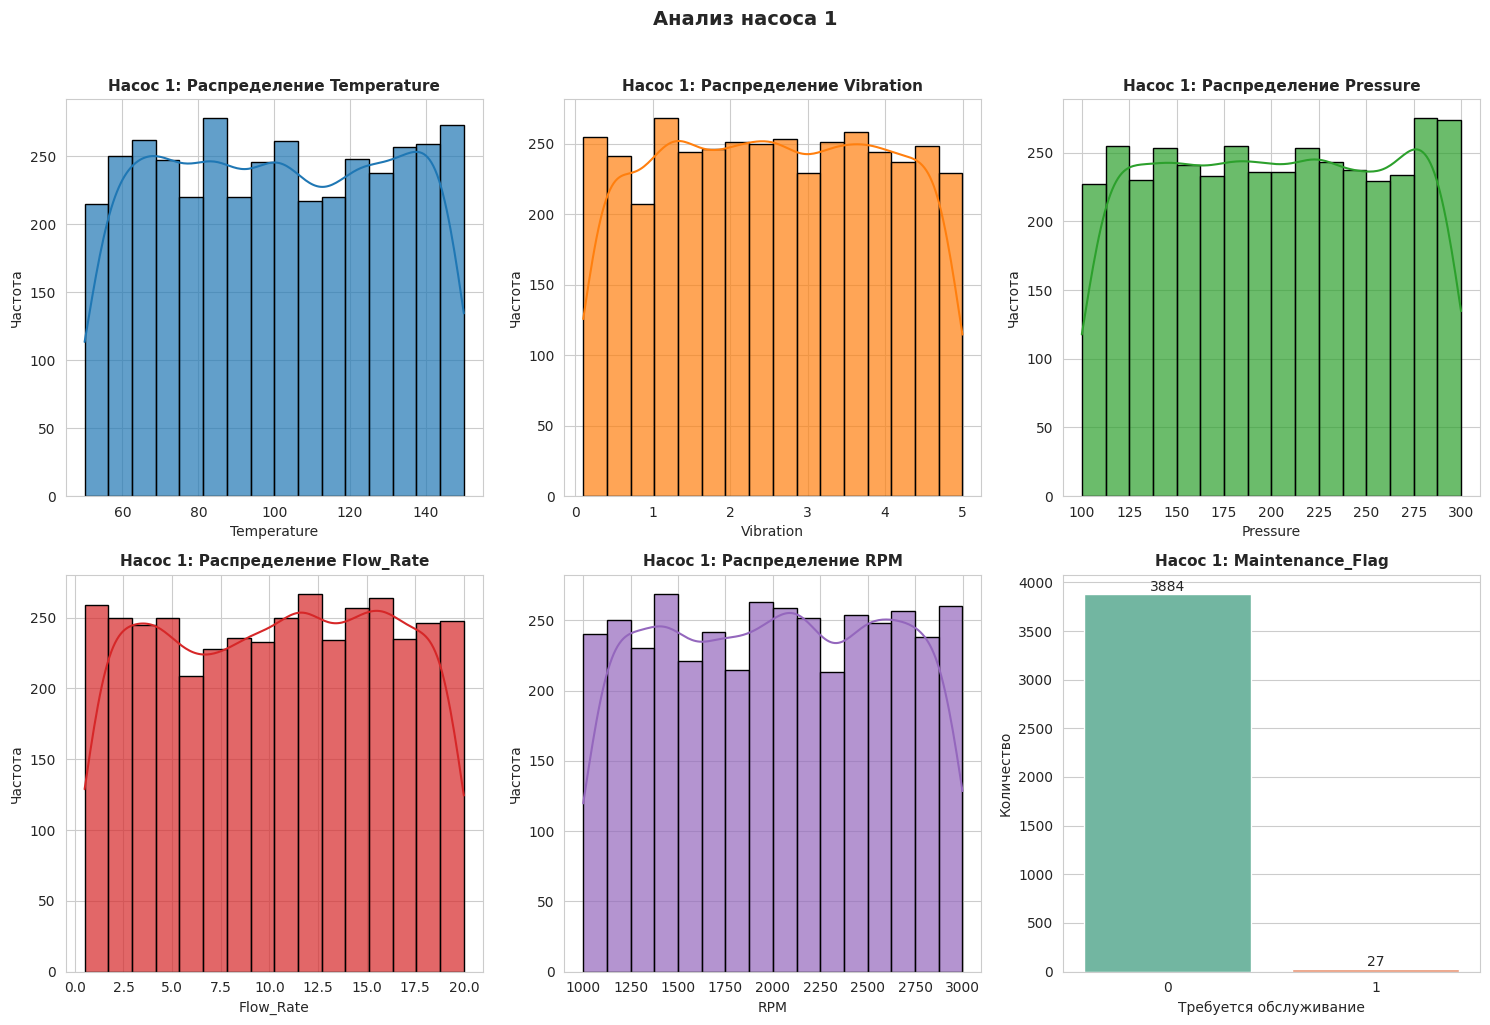

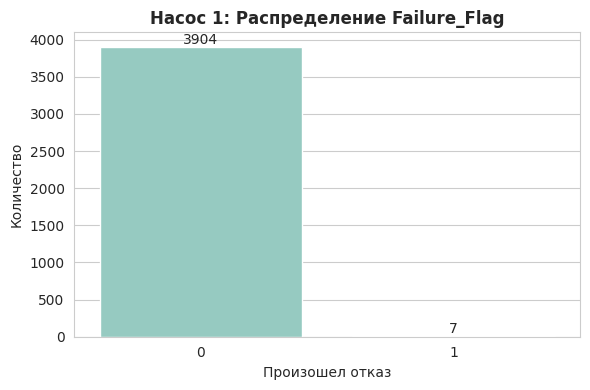

Отказов: 7 (0.2%)
Обслуживаний: 27 (0.7%)



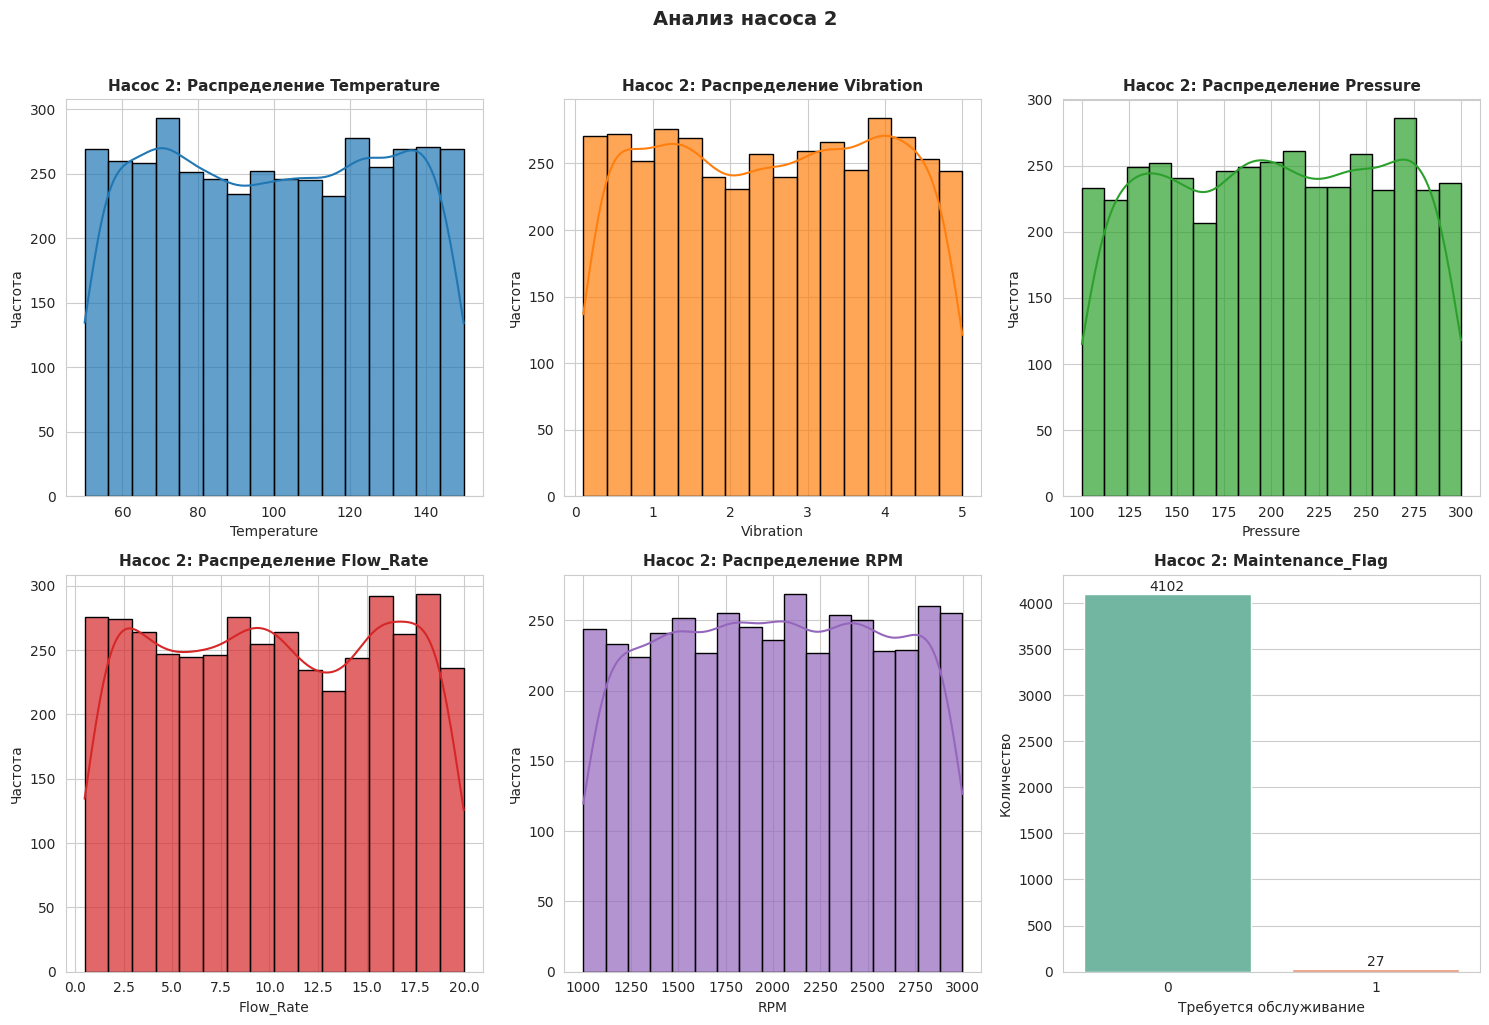

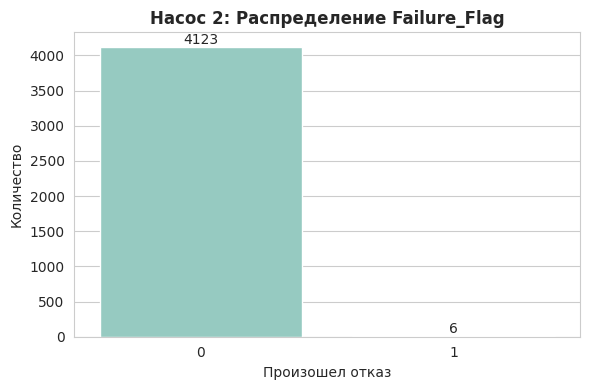

Отказов: 6 (0.1%)
Обслуживаний: 27 (0.7%)



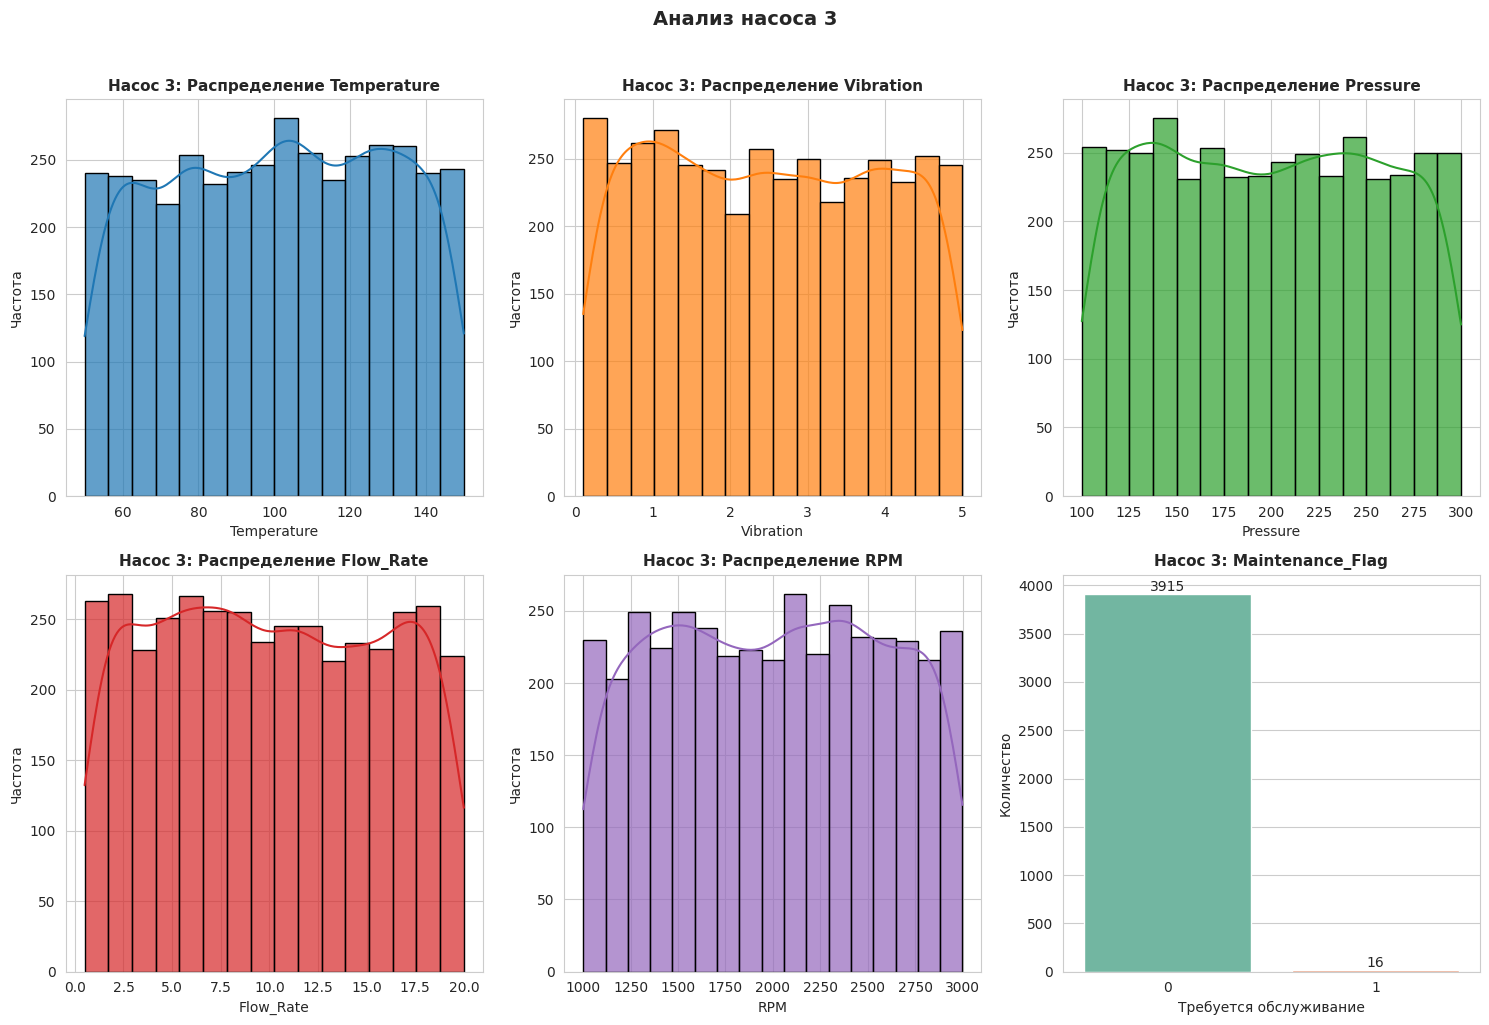

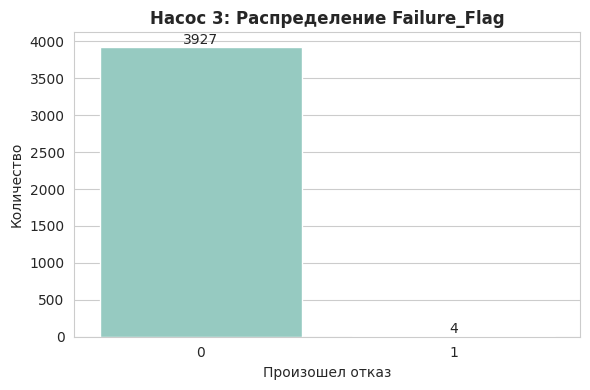

Отказов: 4 (0.1%)
Обслуживаний: 16 (0.4%)



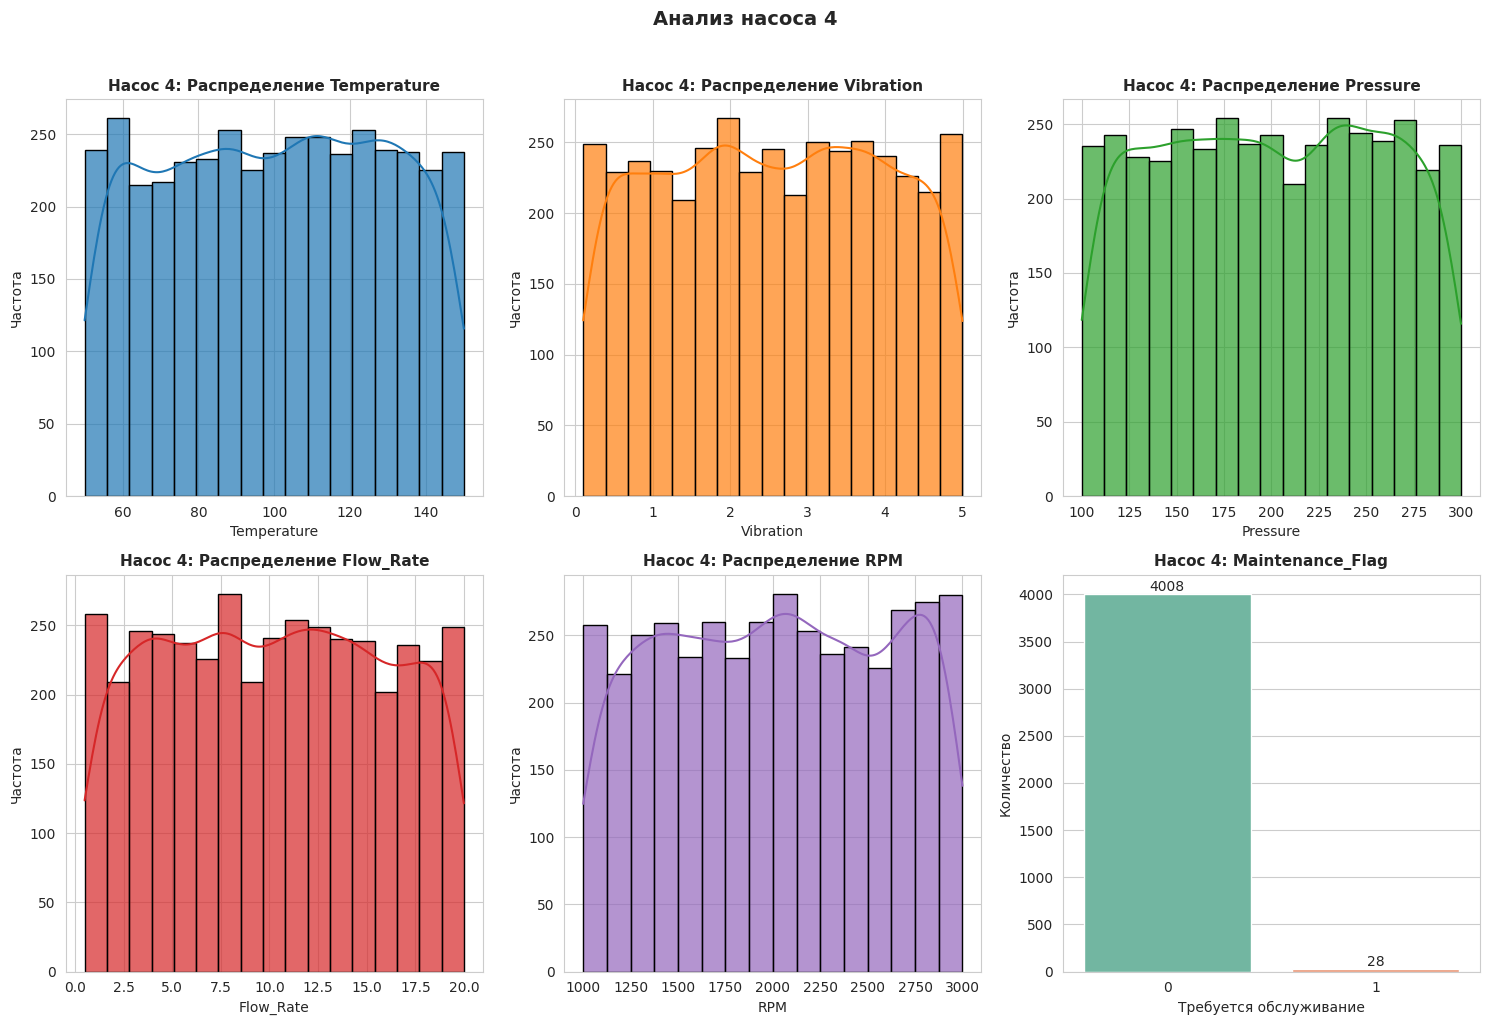

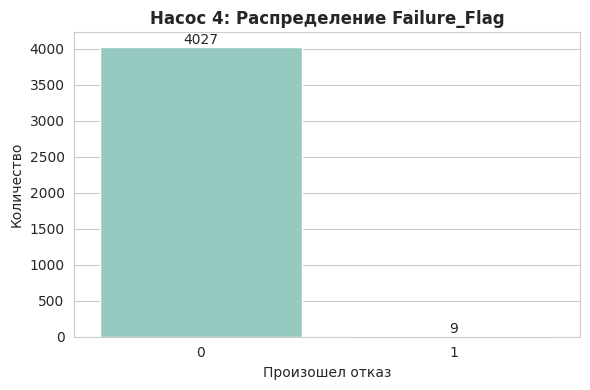

Отказов: 9 (0.2%)
Обслуживаний: 28 (0.7%)



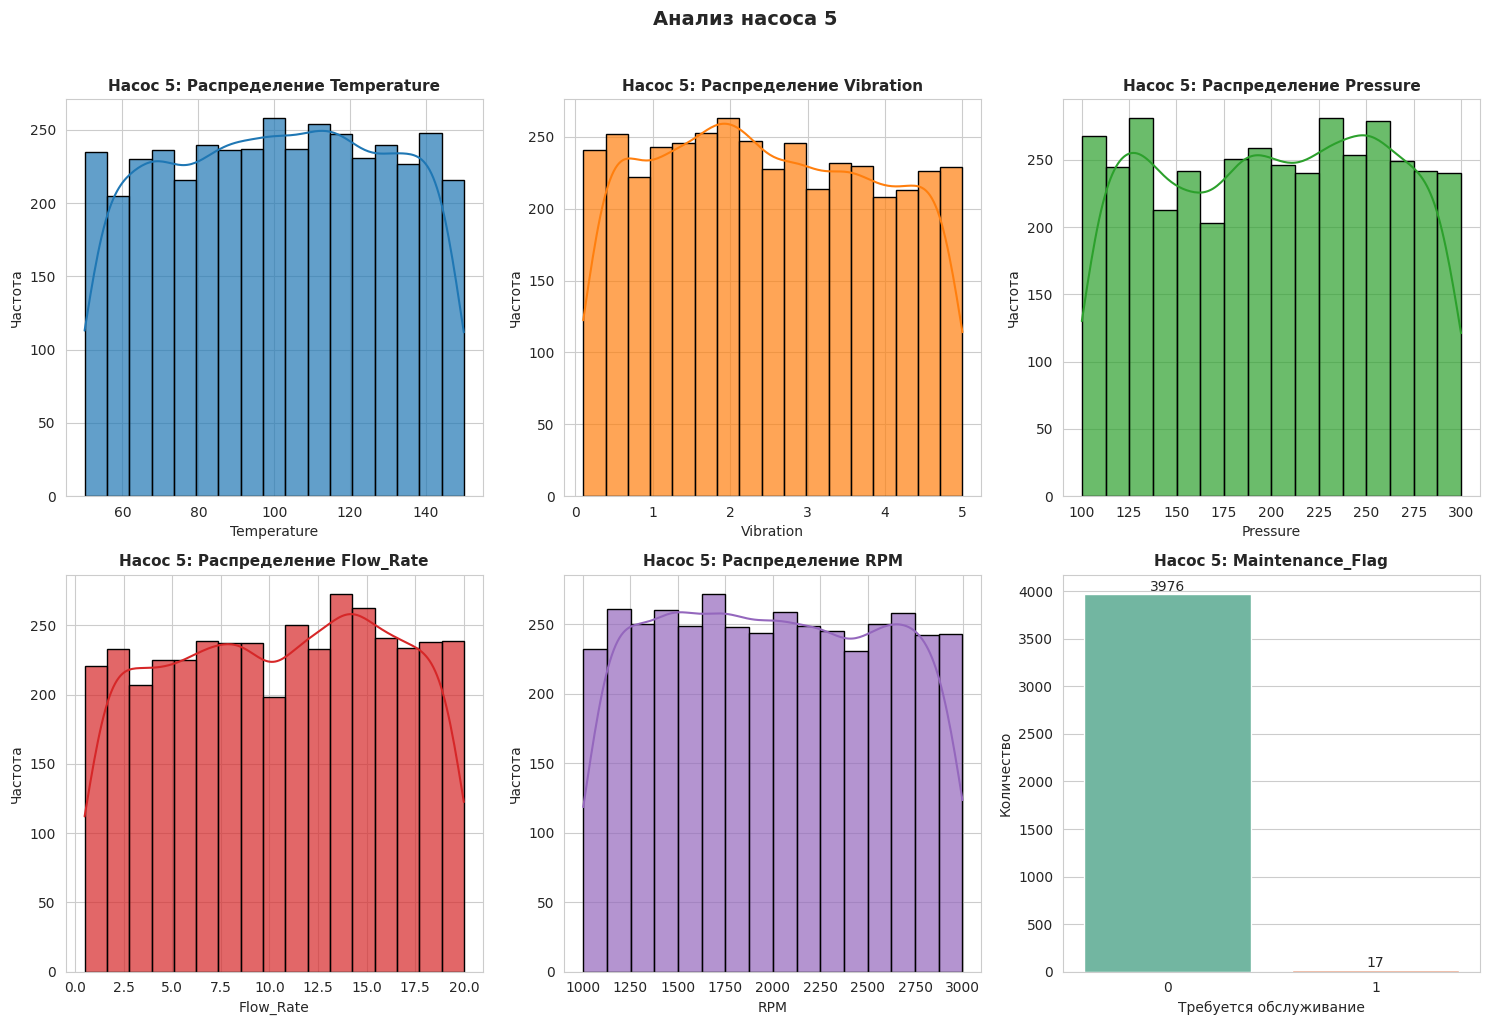

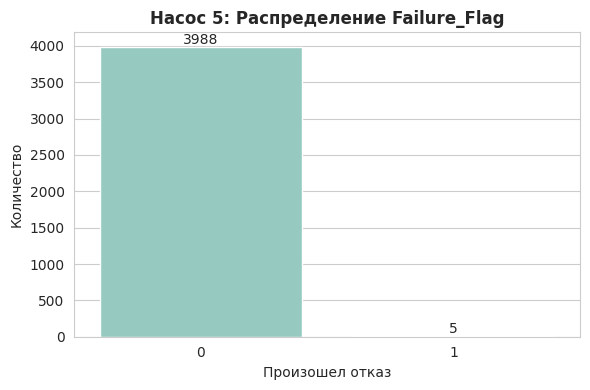

Отказов: 5 (0.1%)
Обслуживаний: 17 (0.4%)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pump_ids = sorted(df['Pump_ID'].unique())

sensor_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM']

# графики для каждого насоса
for pump_id in pump_ids:
    pump_data = df[df['Pump_ID'] == pump_id]

    plt.figure(figsize=(15, 10))

    for i, col in enumerate(sensor_cols, 1):
        plt.subplot(2, 3, i)
        sns.histplot(pump_data[col], kde=True, color=f'C{i-1}', alpha=0.7, edgecolor='black')
        plt.title(f'Насос {pump_id}: Распределение {col}', fontsize=11, fontweight='bold')
        plt.xlabel(col, fontsize=10)
        plt.ylabel('Частота', fontsize=10)


    plt.subplot(2, 3, 6)
    sns.countplot(x='Maintenance_Flag', data=pump_data, palette='Set2')
    plt.title(f'Насос {pump_id}: Maintenance_Flag', fontsize=11, fontweight='bold')
    plt.xlabel('Требуется обслуживание', fontsize=10)
    plt.ylabel('Количество', fontsize=10)

    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=10)


    plt.suptitle(f'Анализ насоса {pump_id}',
                fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(6, 4))
    sns.countplot(x='Failure_Flag', data=pump_data, palette='Set3')
    plt.title(f'Насос {pump_id}: Распределение Failure_Flag', fontsize=12, fontweight='bold')
    plt.xlabel('Произошел отказ', fontsize=10)
    plt.ylabel('Количество', fontsize=10)

    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=10)


    plt.tight_layout()
    plt.show()


    print(f"Отказов: {pump_data['Failure_Flag'].sum()} ({pump_data['Failure_Flag'].mean()*100:.1f}%)")
    print(f"Обслуживаний: {pump_data['Maintenance_Flag'].sum()} ({pump_data['Maintenance_Flag'].mean()*100:.1f}%)")
    print()

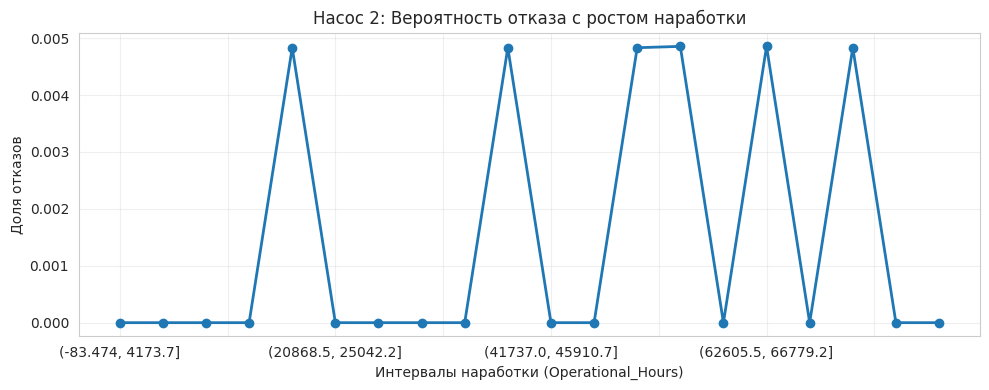

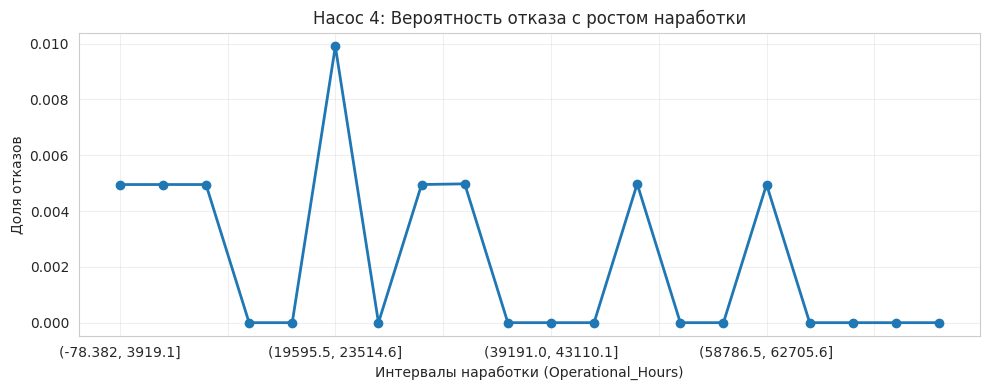

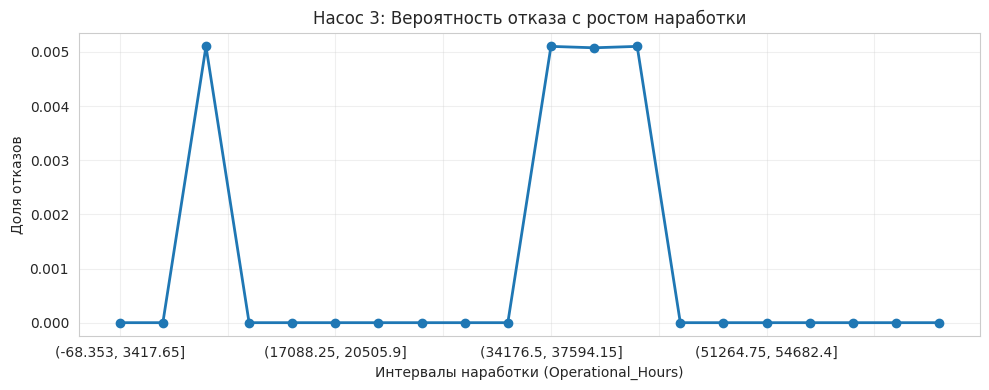

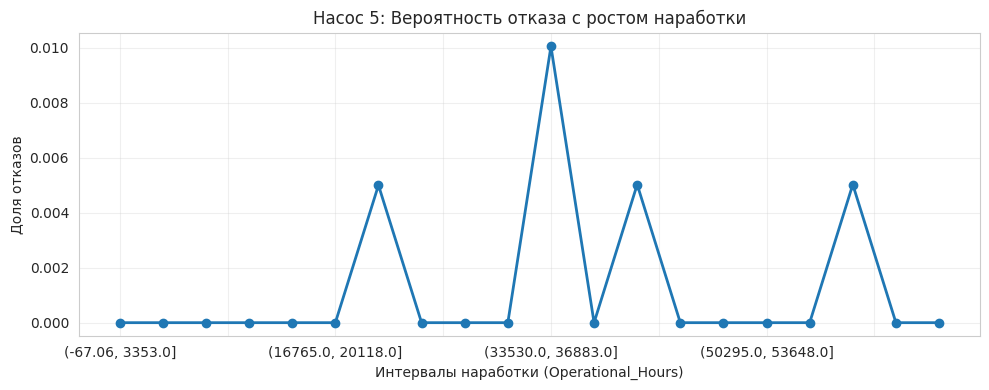

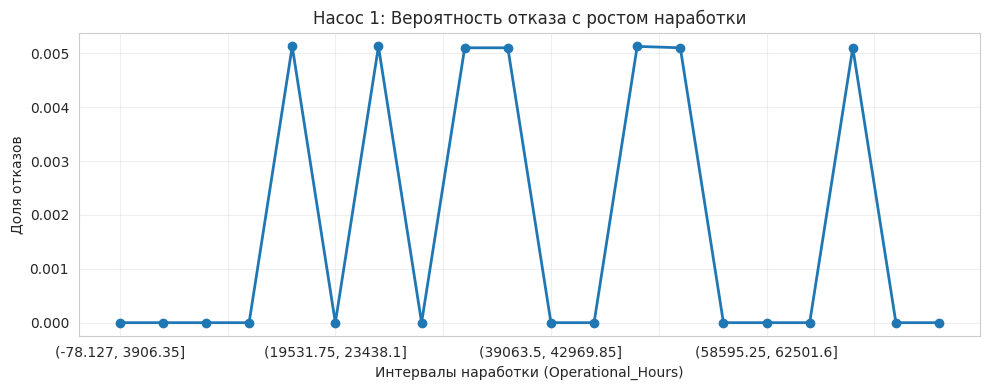

In [ ]:
for pump_id in df['Pump_ID'].unique():
    pump_data = df[df['Pump_ID'] == pump_id].copy()


    pump_data['hours_bin'] = pd.cut(
        pump_data['Operational_Hours'],
        bins=min(20, len(pump_data) // 5)
    )

    failure_rate = pump_data.groupby('hours_bin')['Failure_Flag'].mean()

    plt.figure(figsize=(10, 4))
    failure_rate.plot(marker='o', linewidth=2)

    plt.ylabel('Доля отказов')
    plt.xlabel('Интервалы наработки (Operational_Hours)')
    plt.title(f'Насос {pump_id}: Вероятность отказа с ростом наработки')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

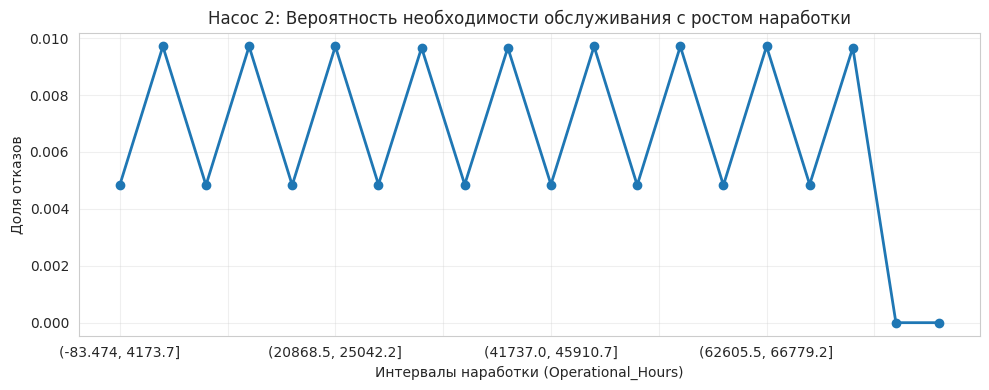

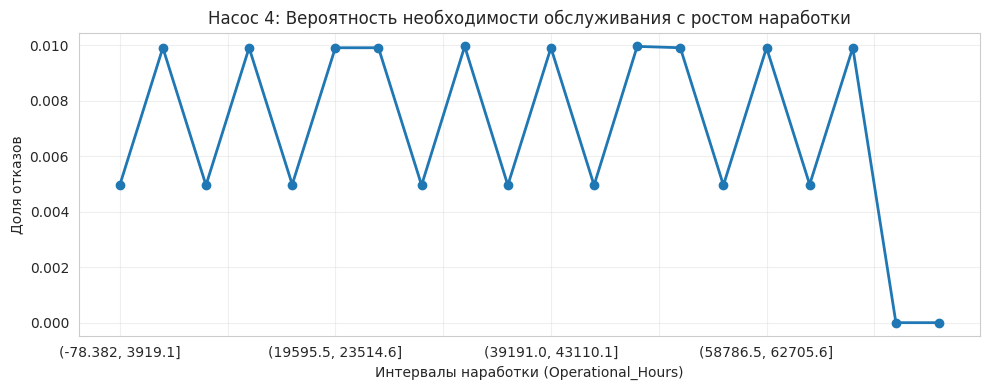

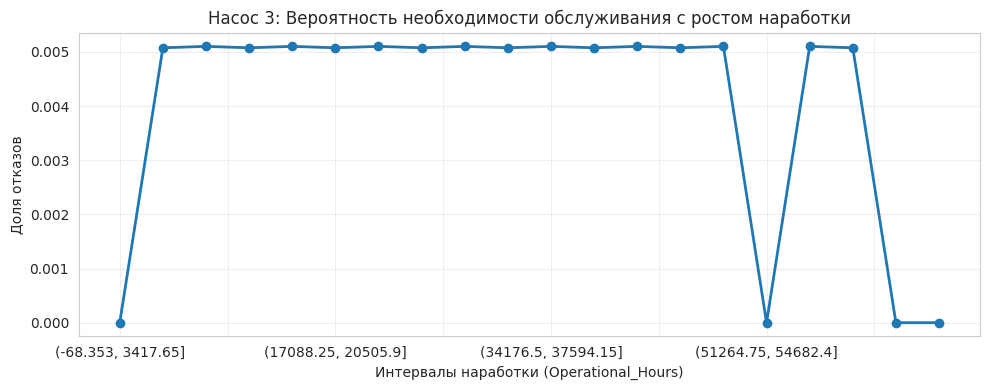

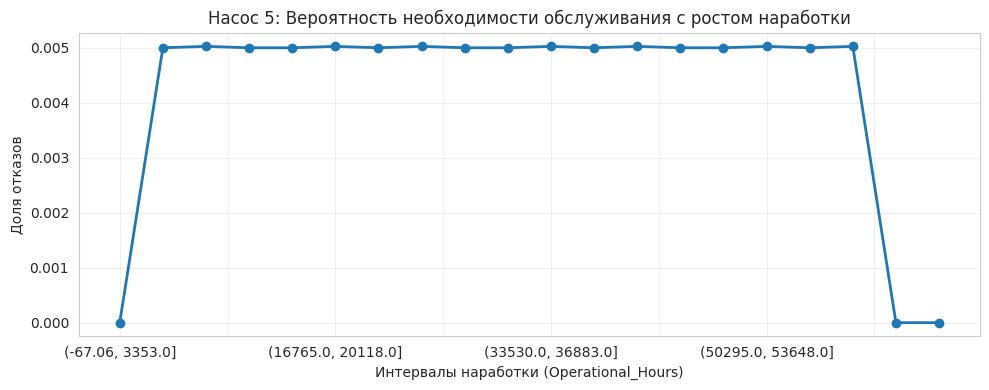

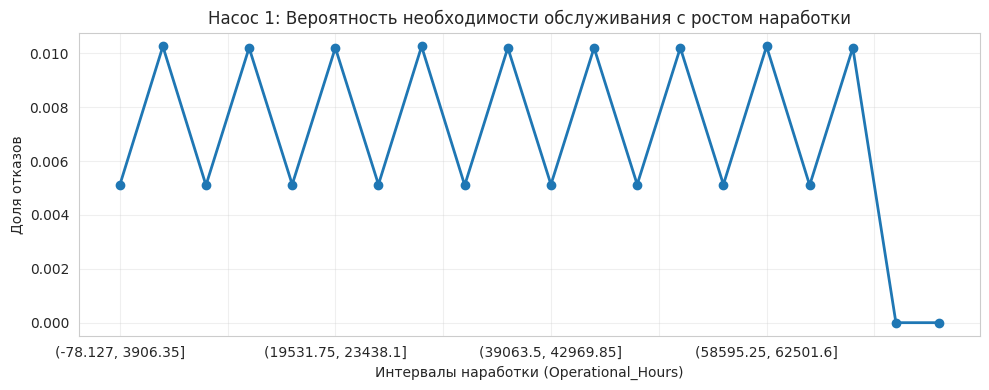

In [ ]:
for pump_id in df['Pump_ID'].unique():
    pump_data = df[df['Pump_ID'] == pump_id].copy()


    pump_data['hours_bin'] = pd.cut(
        pump_data['Operational_Hours'],
        bins=min(20, len(pump_data) // 5)
    )

    failure_rate = pump_data.groupby('hours_bin')['Maintenance_Flag'].mean()

    plt.figure(figsize=(10, 4))
    failure_rate.plot(marker='o', linewidth=2)

    plt.ylabel('Доля отказов')
    plt.xlabel('Интервалы наработки (Operational_Hours)')
    plt.title(f'Насос {pump_id}: Вероятность необходимости обслуживания с ростом наработки')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Как видно, наработка часов слабо коррелирует с отказом и обслуживанием насосного оборудования, так как большинство сценариев не подразумевает деградацию оборудования со временем

**Уже видна проблема, что сценариев отказов и обслуживаний достаточно мало, поэтому скорее всего классический ML здесь не справится. Но это достаточно реалистично для промышленности, так как отказы насосного оборудования случаются реже 1 раза в месяц, без учета человеческого фактора.**

# **FEATURE ENGINEERING**

***Для анализа временных рядов данных датчиков была выполнена сегментация на циклы эксплуатации - периоды между последовательными событиями обслуживания или отказами. Это необходимо для корректного расчёта остаточного ресурса (RUL).***

***RUL (Remaining Useful Life) - сколько часов осталось работать до поломки или обслуживания"***

`RUL = cycle_end - Operational_Hours`



```
cycle_end = max(Operational_Hours) для каждого цикла

Operational_Hours - текущая наработка в часах
```

Для учёта прогресса износа в пределах цикла введён показатель operational_ratio - относительное положение текущего измерения внутри цикла.

In [ ]:

df_new_time = df.sort_values(['Pump_ID', 'Operational_Hours'])

# циклы по обслуживаниям и отказам
df_new_time['event_flag'] = (df_new_time['Maintenance_Flag'] == 1) | (df_new_time['Failure_Flag'] == 1)
df_new_time['cycle_id'] = df_new_time.groupby('Pump_ID')['event_flag'].cumsum()

# RUL
df_new_time['cycle_end'] = df_new_time.groupby(['Pump_ID', 'cycle_id'])['Operational_Hours'].transform('max')
df_new_time['RUL'] = df_new_time['cycle_end'] - df_new_time['Operational_Hours']

df_new_time['operational_ratio'] = df_new_time.groupby(['Pump_ID', 'cycle_id'])['Operational_Hours'] \
                                             .transform(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))

print(f"Статистика RUL:")
print(f"Min RUL: {df_new_time['RUL'].min():.0f} часов")
print(f"Max RUL: {df_new_time['RUL'].max():.0f} часов")
print(f"Mean RUL: {df_new_time['RUL'].mean():.0f} часов")

Статистика RUL:
Min RUL: 0 часов
Max RUL: 9879 часов
Mean RUL: 1681 часов




Получен метод сегментации данных на циклы эксплуатации по событиям
RUL позволяет строить прогнозные модели обслуживания/отказов



*   operational_ratio помогает учитывать нелинейность износа
*   cycle_id обеспечивает корректную обработку временных рядов


Полученные показатели формируют основу для прогнозного моделирования остаточного ресурса оборудования



Было выделено несколько целевых переменных, учитывающих различные типы событий и горизонты прогнозирования. Такой подход позволяет гибко анализировать состояние насосного оборудования и позволит в будущем созадть многоцелевое обучения нейросетевых моделей.


*   Краткосрочный прогноз (48 часов) - для оперативного реагирования на критические отказы
*   Среднесрочный прогноз (100 часов) - обеспечивает возможность планирования работ

Комбинированный таргет повышает устойчивость модели при недостатке данных, что при классических ML-подходах важно


In [ ]:
df = df_new_time
df = df.sort_values(['Pump_ID', 'Operational_Hours']).copy()

# Отказ в ближайшие 48 часов
df['failure_48h'] = 0
FAILURE_HORIZON = 48

for pump_id in df['Pump_ID'].unique():
    pump_data = df[df['Pump_ID'] == pump_id]

    hours = pump_data['Operational_Hours'].values
    failures = pump_data['Failure_Flag'].values

    for i in range(len(pump_data)):
        current_hour = hours[i]
        future_mask = (hours > current_hour) & (hours <= current_hour + FAILURE_HORIZON)
        if future_mask.any() and failures[future_mask].max() > 0:
            df.loc[pump_data.index[i], 'failure_48h'] = 1

# Обслуживание в ближайшие 100 часов
df['maintenance_100h'] = 0
MAINTENANCE_HORIZON = 100

for pump_id in df['Pump_ID'].unique():
    pump_data = df[df['Pump_ID'] == pump_id]

    hours = pump_data['Operational_Hours'].values
    maintenance = pump_data['Maintenance_Flag'].values

    for i in range(len(pump_data)):
        current_hour = hours[i]
        future_mask = (hours > current_hour) & (hours <= current_hour + MAINTENANCE_HORIZON)
        if future_mask.any() and maintenance[future_mask].max() > 0:
            df.loc[pump_data.index[i], 'maintenance_100h'] = 1

# Комбинированный таргет
df['any_event_100h'] = ((df['failure_48h'] == 1) | (df['maintenance_100h'] == 1)).astype(int)


print(f"Распределение:")
print(f"Обслуживания: {df['Maintenance_Flag'].sum():,} ({df['Maintenance_Flag'].mean()*100:.2f}%)")
print(f"Отказ в ближайшие 48ч: {df['failure_48h'].sum():,} ({df['failure_48h'].mean()*100:.2f}%)")
print(f" Обслуживание в ближайшие 100ч : {df['maintenance_100h'].sum():,} ({df['maintenance_100h'].mean()*100:.2f}%)")
print(f" Любое событие в 100ч : {df['any_event_100h'].sum():,} ({df['any_event_100h'].mean()*100:.2f}%)")


Распределение:
Обслуживания: 115 (0.57%)
Отказ в ближайшие 48ч: 62 (0.31%)
 Обслуживание в ближайшие 100ч : 548 (2.74%)
 Любое событие в 100ч : 610 (3.05%)


In [ ]:
# Выбор основного таргета
if df['failure_48h'].mean() < 0.005:
    TARGET_COL = 'any_event_100h'
    TARGET_NAME = 'Любое событие в 100ч'
elif df['failure_48h'].mean() >= df['maintenance_100h'].mean():
    TARGET_COL = 'failure_48h'
    TARGET_NAME = 'Отказ в 48ч'
else:
    TARGET_COL = 'maintenance_100h'
    TARGET_NAME = 'Обслуживание в 100ч'

print(f"Таргет: {TARGET_NAME}")
print(f"   Положительных примеров отказов/обслуживания: {df[TARGET_COL].sum()} ({df[TARGET_COL].mean()*100:.4f}%)")

Таргет: Любое событие в 100ч
   Положительных примеров отказов/обслуживания: 610 (3.0500%)


Попытаемся сформировать интерпретируемое и устойчивое признаковое
пространство для оценки ограничений классических ML-моделей
в условиях редких отказов насосного оборудования

In [ ]:
param_cols = ['Temperature','Vibration','Pressure','Flow_Rate','RPM']

for col in param_cols:
# признаки важные для временных рядов
    df[f'{col}_diff'] = (
        df
        .groupby(['Pump_ID', 'cycle_id'])[col]
        .diff()
        .fillna(0)
    )

    # Скользящее среднее
    df[f'{col}_mean_50'] = (
        df
        .groupby(['Pump_ID', 'cycle_id'])[col]
        .rolling(window=50, min_periods=10)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )

    # Скользящее стандартное отклонение
    df[f'{col}_std_50'] = (
        df
        .groupby(['Pump_ID', 'cycle_id'])[col]
        .rolling(window=50, min_periods=10)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )

# Физические признаки

df['temp_vibration_ratio'] = df['Temperature'] / (df['Vibration'] + 1e-6)

df['power_estimate'] = (df['Flow_Rate'] * df['Pressure']) / 1000

df['efficiency_indicator'] = df['Flow_Rate'] / (df['RPM'] + 1e-6)

df['hours_in_cycle'] = (
    df
    .groupby(['Pump_ID', 'cycle_id'])['Operational_Hours']
    .transform(lambda x: x - x.min())
)

print(f"Всего признаков после {df.shape[1]}")

Всего признаков после 36


In [ ]:
delete_cols = [
    'Pump_ID',
    'cycle_id',
    'Operational_Hours',
    'Maintenance_Flag',
    'Failure_Flag',
    'RUL',
    'operational_ratio',
    'hours_in_cycle',
    'failure_48h',
    'maintenance_100h',
    'any_event_100h',
    'cycle_end'
]

feature_cols = [c for c in df.columns if c not in delete_cols]

X = df[feature_cols]
y = df[TARGET_COL]

pump_ids = df['Pump_ID'].unique()
train_pumps, test_pumps = train_test_split(
    pump_ids,
    test_size=0.3,
    random_state=42
)

train_mask = df['Pump_ID'].isin(train_pumps)
test_mask = df['Pump_ID'].isin(test_pumps)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} записей")
print(f"Test:  {X_test.shape[0]} записей")
print(f"Положительных в train: {y_train.mean()*100:.2f}%")
print(f"Положительных в test:  {y_test.mean()*100:.2f}%")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: 11878 записей
Test:  8122 записей
Положительных в train: 3.33%
Положительных в test:  2.65%


В качестве базовой модели была выбрана модель Random Forest, широко применяемая для задач бинарной классификации и обладающая устойчивостью к шуму и нелинейным зависимостям в данных.

Для оценки качества модели использовались метрики ROC-AUC, precision, recall и F1-score, а также анализ матрицы ошибок. Выбор набора метрик был обусловлен сильным дисбалансом классов и необходимостью оценки способности модели обнаруживать редкие события отказов/обсулживания.

In [ ]:

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
feature_importance = (
    pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
)
print("Топ 5 важных параметров для baseline модели")
for i, row in feature_importance.head(5).iterrows():
    print( f"{row['feature']} ({row['importance']:.4f})")


y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred, zero_division=0)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
print("=" * 50)
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Матрица ошибок")

print("=" * 50)
print("       ┌───────┬───────┐")
print("       │  TN   │  FP   │")
print(f"       │ {tn:^5d} │ {fp:^5d} │")
print("       ├───────┼───────┤")
print("       │  FN   │  TP   │")
print(f"       │ {fn:^5d} │ {tp:^5d} │")
print("       └───────┴───────┘")

Топ 5 важных параметров для baseline модели
Vibration_mean_50 (0.0973)
Pressure_std_50 (0.0920)
Vibration_std_50 (0.0884)
Pressure_mean_50 (0.0778)
RPM_mean_50 (0.0716)
ROC-AUC:   0.6036
F1-score:  0.0561
Precision: 0.0339
Recall:    0.1628
Матрица ошибок
       ┌───────┬───────┐
       │  TN   │  FP   │
       │ 6909  │  998  │
       ├───────┼───────┤
       │  FN   │  TP   │
       │  180  │  35   │
       └───────┴───────┘


Анализ важности признаков показал, что наибольшее влияние оказывают показатели вибрации и давления.

В результате обучения базовой модели Random Forest без утечки целевой информации было получено значение ROC-AUC 0.60. Анализ матрицы ошибок показал, что модель корректно обнаруживает лишь около 16% событий при значительном количестве ложных срабатываний.

**Базовая модель демонстрирует низкую чувствительность к событиям отказа, что делает её неприменимой для раннего предупреждения в промышленной среде.**

Существенным ограничением данного подхода является его одноцелевой характер: каждая целевая переменная (прогноз отказа и прогноз обслуживания) требует обучения отдельной модели, что исключает возможность совместного использования информации между задачами.

In [ ]:
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

sensors = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM']
results = []

for sensor in sensors:
    valid_data = df[[sensor, 'Failure_Flag']].dropna()
    x = valid_data[sensor]
    y = valid_data['Failure_Flag']

    pearson_corr, pearson_p = pearsonr(x, y)

    spearman_corr, spearman_p = spearmanr(x, y)

    results.append({
        'Датчик': sensor,
        'Пирсон': pearson_corr,
        'p-value Пирсон': pearson_p,
        'Спирмен': spearman_corr,
        'p-value Спирмен': spearman_p
    })

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

     Датчик  Пирсон  p-value Пирсон  Спирмен  p-value Спирмен
Temperature  0.0831          0.0000   0.0599           0.0000
  Vibration  0.0853          0.0000   0.0622           0.0000
   Pressure -0.0466          0.0000  -0.0427           0.0000
  Flow_Rate -0.0650          0.0000  -0.0527           0.0000
        RPM  0.0097          0.1681   0.0067           0.3403


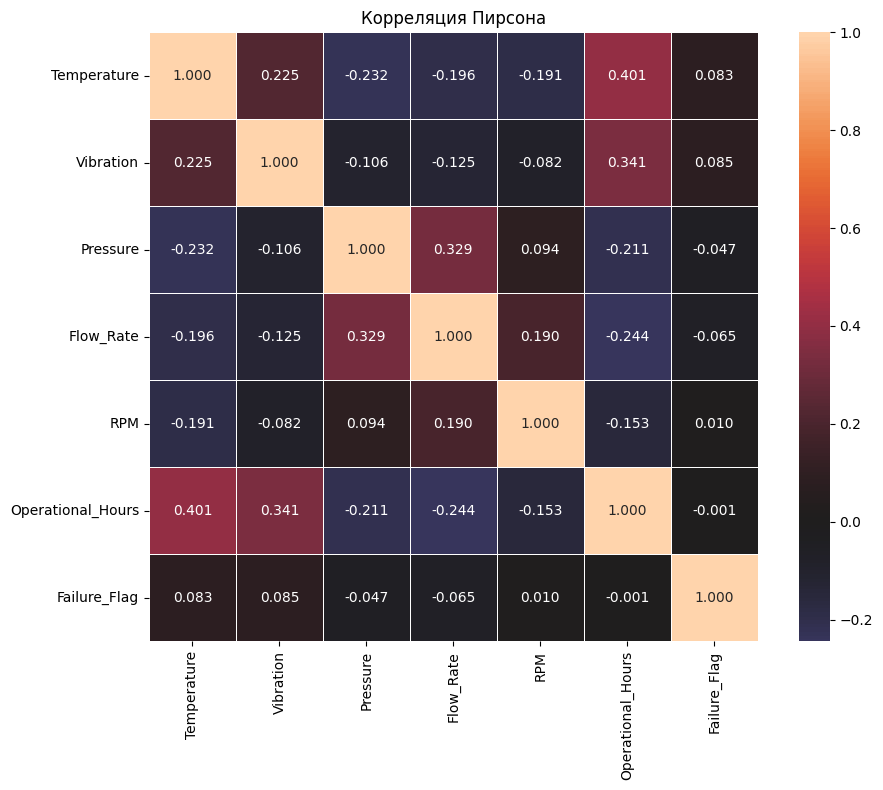

In [ ]:
all_features = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM',
                'Operational_Hours', 'Failure_Flag']

spearman_matrix = df[all_features].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_matrix,
            annot=True,
            fmt='.3f',
            center=0,
            square=True,
            linewidths=0.5)
plt.title("Корреляция Пирсона")
plt.tight_layout()
plt.show()

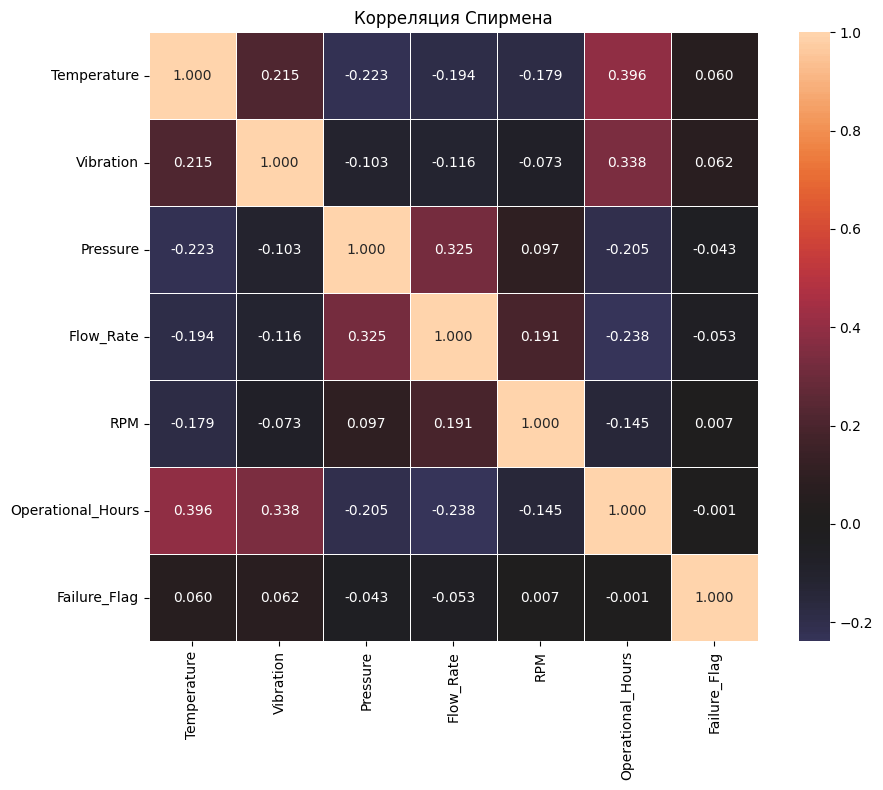

In [ ]:
all_features = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM',
                'Operational_Hours', 'Failure_Flag']

spearman_matrix = df[all_features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_matrix,
            annot=True,
            fmt='.3f',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Корреляция Спирмена')
plt.tight_layout()
plt.show()

#**ARIMA/ARIMAX**

     Датчик ADF-статистика  p-value
Temperature        -3.2967 0.015029
  Vibration        -8.5431 0.000000
   Pressure       -11.5977 0.000000
  Flow_Rate        -7.5447 0.000000
        RPM        -4.9639 0.000026


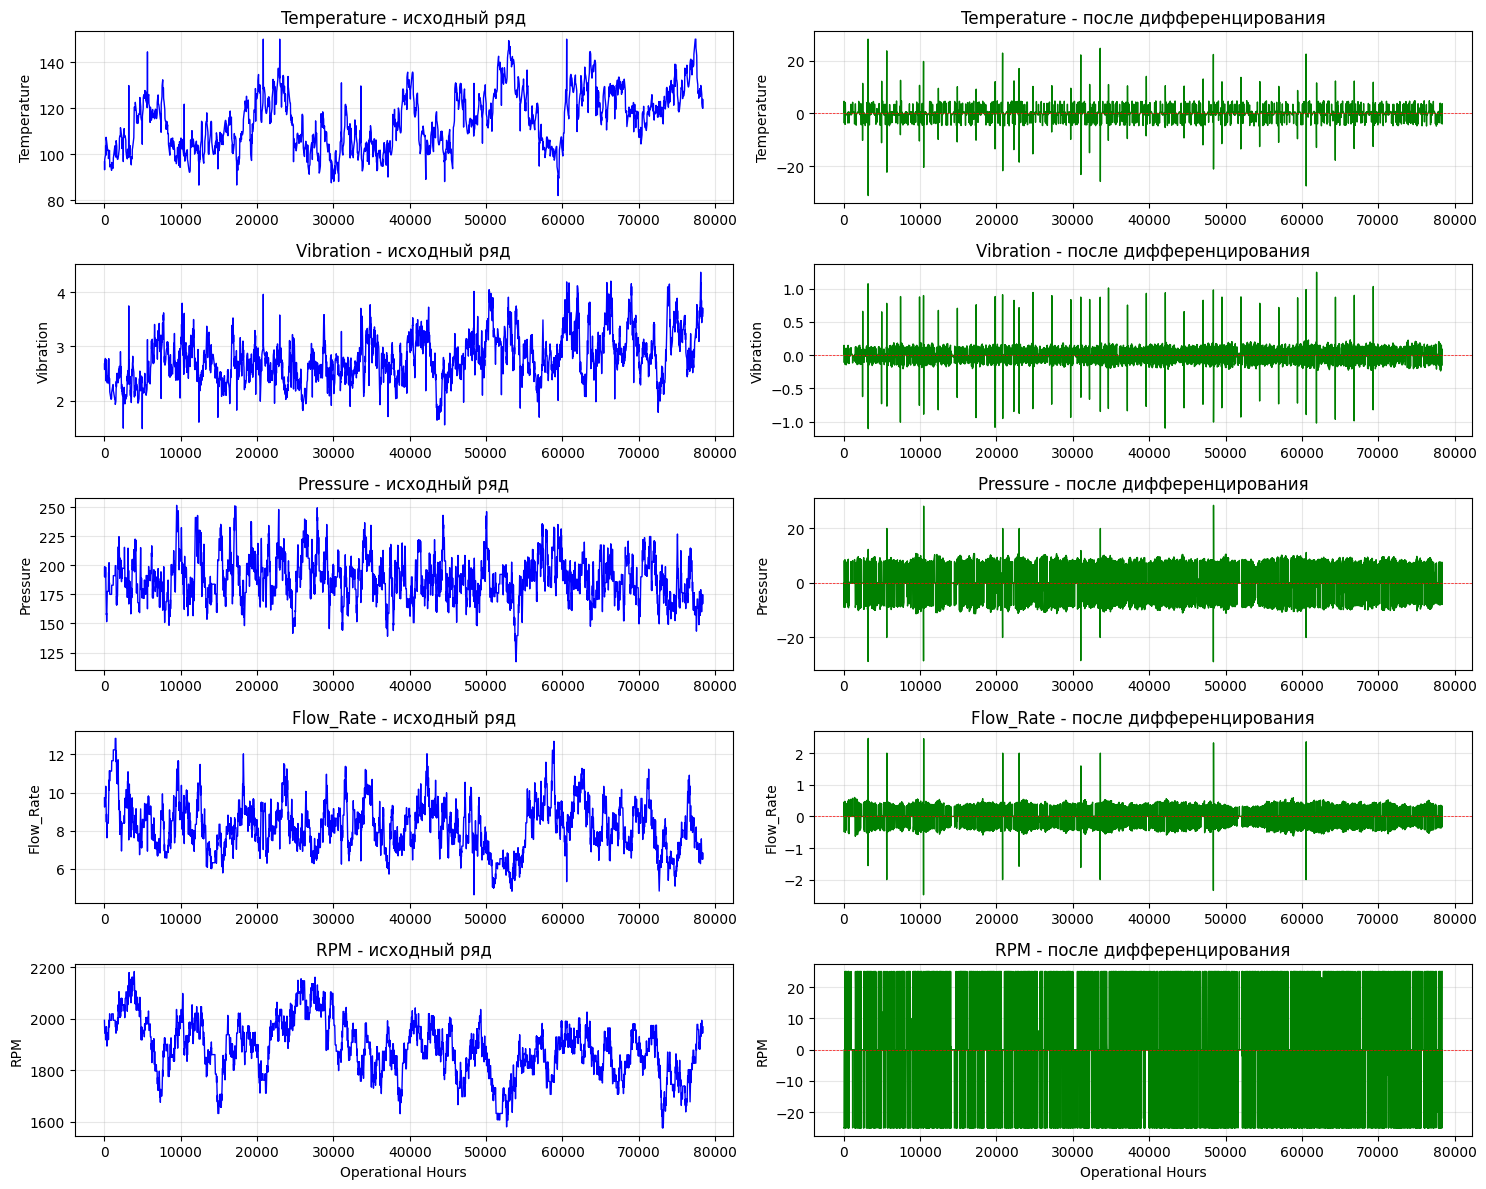

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# По насосу с наибольшим количеством отказов
pump_id = 4
pump_data = df[df['Pump_ID'] == pump_id].sort_values('Operational_Hours')
pump_data = pump_data.set_index('Operational_Hours')

sensors = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM']

results = []
for sensor in sensors:
    series = pump_data[sensor].dropna()
    result = adfuller(series)
    is_stationary = result[1] <= 0.05
    results.append({
        'Датчик': sensor,
        'ADF-статистика': f"{result[0]:.4f}",
        'p-value': f"{result[1]:.6f}"
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


fig, axes = plt.subplots(len(sensors), 2, figsize=(15, 12))

for i, sensor in enumerate(sensors):

    axes[i, 0].plot(pump_data.index, pump_data[sensor], linewidth=1, color='blue')
    axes[i, 0].set_title(f'{sensor} - исходный ряд')
    axes[i, 0].set_ylabel(sensor)
    axes[i, 0].grid(True, alpha=0.3)

    diff_series = pump_data[sensor].diff().dropna()
    axes[i, 1].plot(diff_series.index, diff_series, linewidth=1, color='green')
    axes[i, 1].set_title(f'{sensor} - после дифференцирования')
    axes[i, 1].set_ylabel(sensor)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].axhline(y=0, color='red', linestyle='--', linewidth=0.5)

axes[-1, 0].set_xlabel('Operational Hours')
axes[-1, 1].set_xlabel('Operational Hours')
plt.tight_layout()
plt.show()

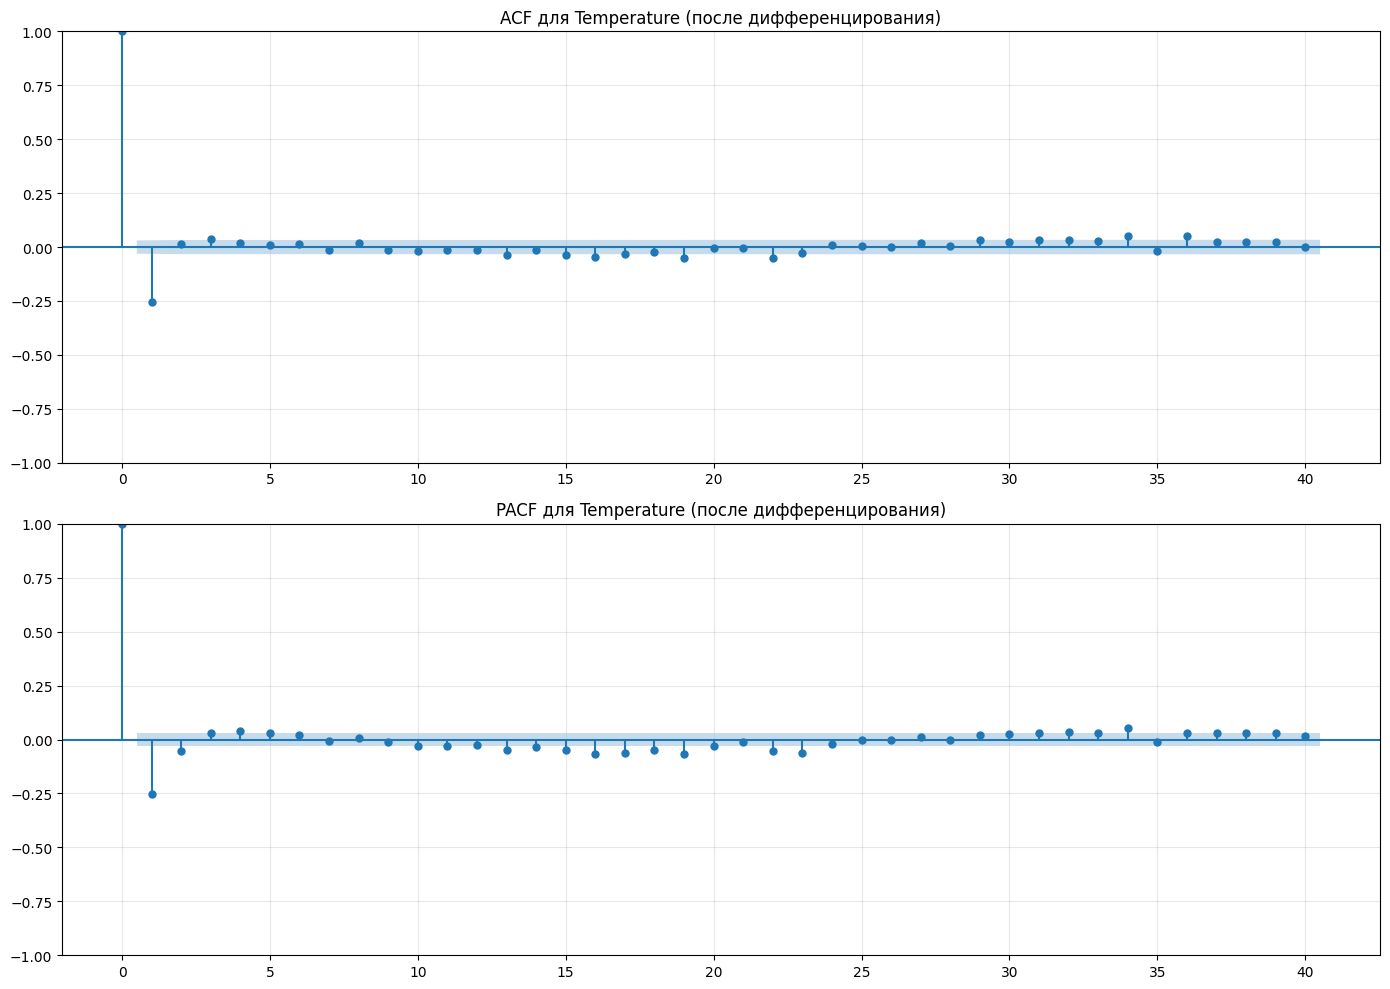

In [ ]:
sensor_example = 'Temperature'
series_diff = pump_data[sensor_example].diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
plot_acf(series_diff, lags=40, ax=ax1)
ax1.set_title(f'ACF для {sensor_example} (после дифференцирования)')
ax1.grid(True, alpha=0.3)

plot_pacf(series_diff, lags=40, ax=ax2)
ax2.set_title(f'PACF для {sensor_example} (после дифференцирования)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

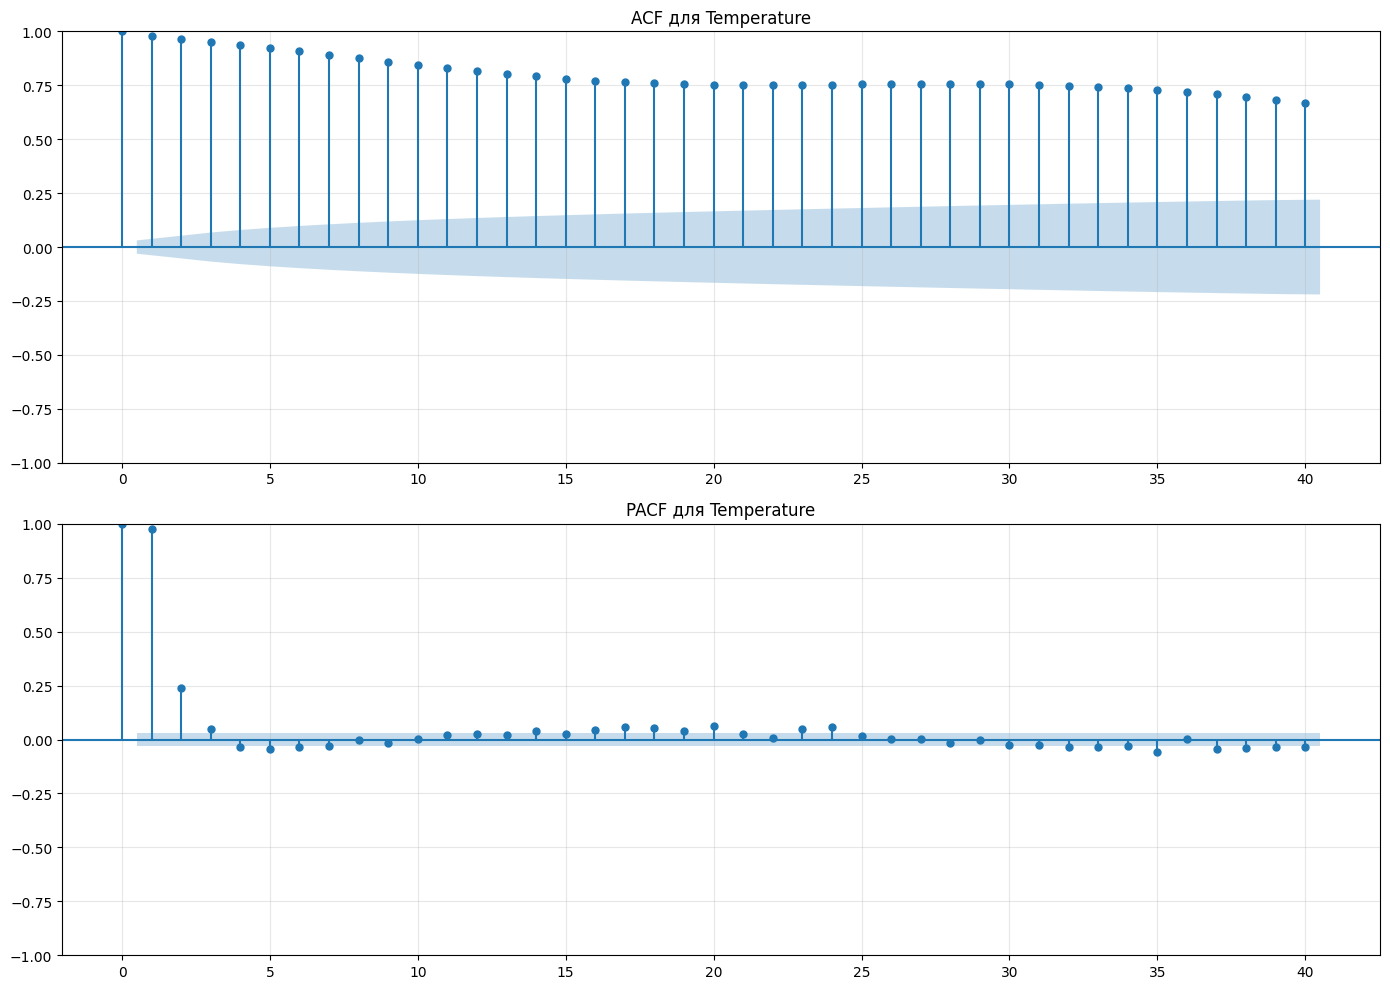

In [ ]:
#до дифференциирования
sensor_example = 'Temperature'
series = pump_data[sensor_example].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(series, lags=40, ax=ax1)
ax1.set_title(f'ACF для {sensor_example}')
ax1.grid(True, alpha=0.3)

plot_pacf(series, lags=40, ax=ax2)
ax2.set_title(f'PACF для {sensor_example}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


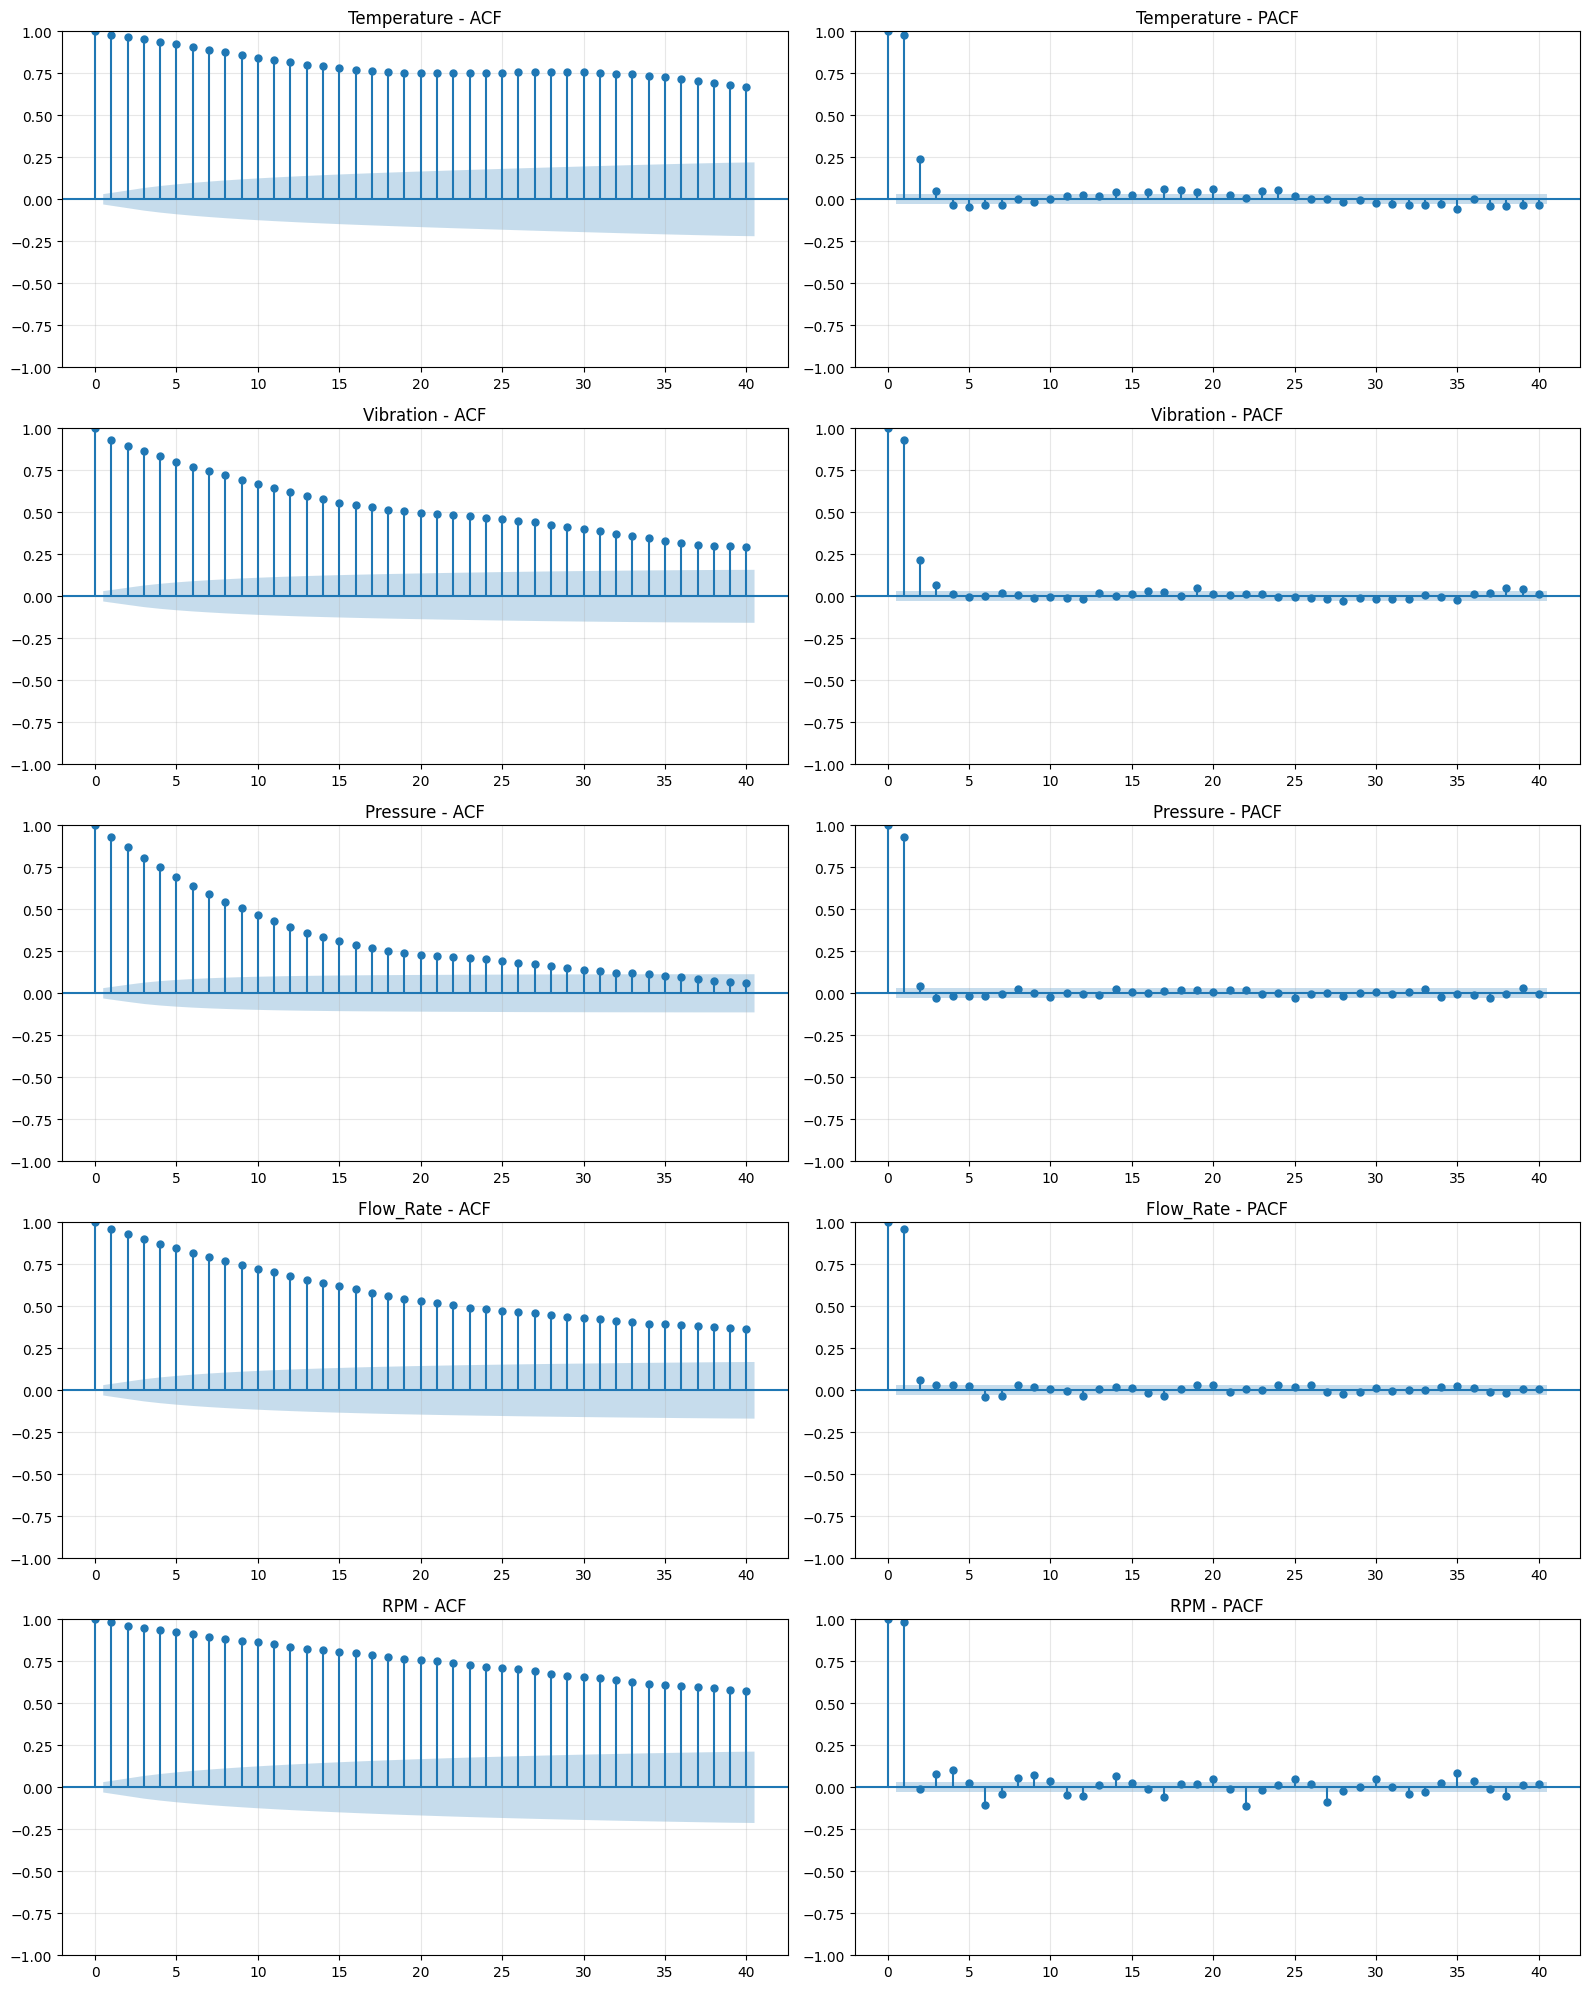

In [ ]:

fig, axes = plt.subplots(len(sensors), 2, figsize=(16, 20))

for i, sensor in enumerate(sensors):
    series = pump_data[sensor].dropna()

    # ACF
    plot_acf(series, lags=40, ax=axes[i, 0])
    axes[i, 0].set_title(f'{sensor} - ACF')
    axes[i, 0].grid(True, alpha=0.3)

    # PACF
    plot_pacf(series, lags=40, ax=axes[i, 1])
    axes[i, 1].set_title(f'{sensor} - PACF')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модель

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix

class ARIMAExperiment:
    def __init__(self, df):
        self.df = df.sort_values(['Pump_ID', 'Operational_Hours']).reset_index(drop=True)
        self.sensors = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM']
        self.exogenous = ['Maintenance_Flag', 'Operational_Hours']
        self.results = {}
        self.horizon = 24

    def prepare_data(self, pump_id):
        pump_data = self.df[self.df['Pump_ID'] == pump_id].copy()
        pump_data = pump_data.set_index('Operational_Hours')

        ts_data = {sensor: pump_data[sensor].dropna() for sensor in self.sensors}
        exog_data = pump_data[[col for col in self.exogenous if col in pump_data.columns]].dropna()

        failure_flags = pump_data['Failure_Flag'] if 'Failure_Flag' in pump_data.columns else None

        return ts_data, exog_data, failure_flags

    def fit_arima_grid(self, series, exog=None, order=(1,1,1), horizon=48):
        try:
            if len(series) < horizon + 50:
                return np.zeros(horizon)


            train_series = series.iloc[:-horizon]
            test_series = series.iloc[-horizon:]

            if exog is not None and len(exog) >= horizon + 50:
                common_idx = series.index.intersection(exog.index)
                if len(common_idx) < horizon + 50:
                    return np.zeros(horizon)

                series_sync = series.loc[common_idx]
                exog_sync = exog.loc[common_idx]

                train_exog = exog_sync.iloc[:-horizon]
                test_exog = exog_sync.iloc[-horizon:]

                model = SARIMAX(
                    train_series,
                    exog=train_exog,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
            else:
                model = ARIMA(train_series, order=order)

            fitted = model.fit(method='lbfgs', maxiter=200)

            if exog is not None and len(exog) >= horizon + 50:
                predictions = fitted.forecast(steps=horizon, exog=test_exog)
            else:
                predictions = fitted.forecast(steps=horizon)

            errors = np.abs(test_series.values[:len(predictions)] - predictions)

            if len(errors) < horizon:
                errors = np.pad(errors, (0, horizon - len(errors)), 'constant')

            if np.std(errors) > 0:
                z_scores = (errors - np.mean(errors)) / np.std(errors)
                probabilities = 1 / (1 + np.exp(-z_scores))
            else:
                probabilities = np.ones(horizon) * 0.5

            return probabilities

        except Exception as e:
            print(f"Ошибка для насоса: {e}")
            return np.zeros(horizon)

    def get_model_probas(self, pump_id, model_config, horizon=24):
        ts_data, exog_data, failure_flags = self.prepare_data(pump_id)
        all_probabilities = []

        for sensor in self.sensors:
            series = ts_data.get(sensor)
            if series is None or len(series) < 100:
                continue

            if model_config['type'] == 'arimax' and len(exog_data) < 100:
                continue

            probabilities = self.fit_arima_grid(
                series,
                exog_data if model_config['type'] == 'arimax' else None,
                order=model_config['order'],
                horizon=horizon
            )

            if len(probabilities) == horizon:
                all_probabilities.append(probabilities)

        if not all_probabilities:
            return np.zeros(horizon)

        final_probabilities = np.mean(all_probabilities, axis=0)

        if failure_flags is not None and len(failure_flags) >= horizon:
            recent_failures = failure_flags.iloc[-horizon:].values

            if np.sum(recent_failures) > 0:
                failure_boost = recent_failures * 0.5
                final_probabilities = np.clip(final_probabilities + failure_boost, 0, 1)

        return final_probabilities

    def define_model_configs(self):
        configs = {
            'ARIMA(0,1,0)': {'type': 'arima', 'order': (0,1,0)},
            'ARIMA(1,1,0)': {'type': 'arima', 'order': (1,1,0)},
            'ARIMA(1,1,1)': {'type': 'arima', 'order': (1,1,1)},
            'ARIMA(2,1,1)': {'type': 'arima', 'order': (2,1,1)},
            'ARIMA(2,1,2)': {'type': 'arima', 'order': (2,1,2)},
            'ARIMA(3,1,1)': {'type': 'arima', 'order': (3,1,1)},
            'ARIMA(1,0,1)': {'type': 'arima', 'order': (1,0,1)},
            'ARIMA(1,2,1)': {'type': 'arima', 'order': (1,2,1)},
            'ARIMAX(1,1,1)': {'type': 'arimax', 'order': (1,1,1)},
            'ARIMAX(2,1,1)': {'type': 'arimax', 'order': (2,1,1)},
            'ARIMAX(2,1,2)': {'type': 'arimax', 'order': (2,1,2)},
            'ARIMAX(1,1,0)': {'type': 'arimax', 'order': (1,1,0)},
        }
        return configs

    def run_full_grid_search(self):
        configs = self.define_model_configs()
        all_probas = {}

        for pump_id in self.df['Pump_ID'].unique():
            pump_probas = {}

            for config_name, config in configs.items():
                proba = self.get_model_probas(pump_id, config, horizon=self.horizon)
                pump_probas[config_name] = proba

            all_probas[pump_id] = pump_probas

        return all_probas, configs

    def compute_metrics_table(self, probas_dict):

        all_predictions = {}
        pump_slices = {}
        current_idx = 0

        for pump_id in self.df['Pump_ID'].unique():
            pump_data = self.df[self.df['Pump_ID'] == pump_id]
            n_rows = len(pump_data)
            pump_slices[pump_id] = (current_idx, current_idx + n_rows)
            current_idx += n_rows

        y_true = self.df['Failure_Flag'].values

        first_pump = list(probas_dict.keys())[0]
        for model_name in probas_dict[first_pump].keys():
            all_predictions[model_name] = np.zeros(len(self.df))

            for pump_id, pump_probas in probas_dict.items():
                if model_name in pump_probas:
                    start_idx, end_idx = pump_slices[pump_id]
                    probas = pump_probas[model_name]

                    n_pump_rows = end_idx - start_idx
                    if n_pump_rows >= len(probas):

                        insert_start = start_idx + (n_pump_rows - len(probas))
                        all_predictions[model_name][insert_start:end_idx] = probas[:n_pump_rows]
                    else:
                        all_predictions[model_name][start_idx:end_idx] = probas[:n_pump_rows]

        results = {}

        for model_name, y_pred_proba in all_predictions.items():

            if np.sum(y_pred_proba) == 0:
                continue

            try:
                roc_auc = roc_auc_score(y_true, y_pred_proba)
            except:
                roc_auc = 0.5
            thresholds = np.arange(0.1, 0.9, 0.05)
            best_f1, best_precision, best_recall, best_thresh = 0, 0, 0, 0.5

            for thresh in thresholds:
                y_pred = (y_pred_proba > thresh).astype(int)
                precision, recall, f1, _ = precision_recall_fscore_support(
                    y_true, y_pred, average='binary', zero_division=0)

                if f1 > best_f1:
                    best_f1, best_precision, best_recall, best_thresh = f1, precision, recall, thresh

            y_pred_best = (y_pred_proba > best_thresh).astype(int)

            tp = np.sum((y_pred_best == 1) & (y_true == 1))
            fp = np.sum((y_pred_best == 1) & (y_true == 0))
            fn = np.sum((y_pred_best == 0) & (y_true == 1))
            tn = np.sum((y_pred_best == 0) & (y_true == 0))

            total_failures = np.sum(y_true)
            if total_failures > 0:
                failure_rate = f"{tp}/{total_failures} ({tp/total_failures*100:.1f}%)"
            else:
                failure_rate = f"{tp}/0 (0%)"

            results[model_name] = {
                'ROC-AUC': f"{roc_auc:.3f}",
                'Precision': f"{best_precision:.3f}",
                'Recall': f"{best_recall:.3f}",
                'F1': f"{best_f1:.3f}",
                'Failures': failure_rate,
                'Threshold': f"{best_thresh:.2f}",
                'TP': tp,
                'FP': fp,
                'FN': fn,
                'TN': tn
            }

        return pd.DataFrame(results).T

In [ ]:
def run_arima_parameter_benchmark(df):

    experiment = ARIMAExperiment(df)

    probas, configs = experiment.run_full_grid_search()
    metrics_df = experiment.compute_metrics_table(probas)

    if not metrics_df.empty:
        metrics_df_sorted = metrics_df.sort_values('ROC-AUC', ascending=False)
        display_cols = ['ROC-AUC', 'Precision', 'Recall', 'F1', 'Failures']
        print(metrics_df_sorted[display_cols].to_string())

        top3 = metrics_df_sorted.head(3)
        print(f"\n ТОП-3:")
        for idx, row in top3.iterrows():
            print(f"  {idx}: ROC-AUC {row['ROC-AUC']}, F1 {row['F1']}, Отказы: {row['Failures']}")

    return probas, metrics_df

In [ ]:
probas, metrics = run_arima_parameter_benchmark(df)
print(metrics)

Насос 1: тестируем 12 моделей...
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keywor

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

Насос 2: тестируем 12 моделей...
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keywor

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

Насос 3: тестируем 12 моделей...
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keywor

...

Насос 4: тестируем 12 моделей...
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keywor

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
 

Насос 5: тестируем 12 моделей...
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keyword argument 'maxiter'
Ошибка для насоса: ARIMA.fit() got an unexpected keywor

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
 

              ROC-AUC Precision Recall     F1     Failures
ARIMAX(1,1,1)   0.497     0.000  0.000  0.000  0/31 (0.0%)
ARIMAX(2,1,1)   0.497     0.000  0.000  0.000  0/31 (0.0%)
ARIMAX(2,1,2)   0.497     0.000  0.000  0.000  0/31 (0.0%)
ARIMAX(1,1,0)   0.497     0.000  0.000  0.000  0/31 (0.0%)

 ТОП-3:
  ARIMAX(1,1,1): ROC-AUC 0.497, F1 0.000, Отказы: 0/31 (0.0%)
  ARIMAX(2,1,1): ROC-AUC 0.497, F1 0.000, Отказы: 0/31 (0.0%)
  ARIMAX(2,1,2): ROC-AUC 0.497, F1 0.000, Отказы: 0/31 (0.0%)
              ROC-AUC Precision Recall     F1     Failures Threshold TP  FP  \
ARIMAX(1,1,1)   0.497     0.000  0.000  0.000  0/31 (0.0%)      0.50  0  60   
ARIMAX(2,1,1)   0.497     0.000  0.000  0.000  0/31 (0.0%)      0.50  0  60   
ARIMAX(2,1,2)   0.497     0.000  0.000  0.000  0/31 (0.0%)      0.50  0  60   
ARIMAX(1,1,0)   0.497     0.000  0.000  0.000  0/31 (0.0%)      0.50  0  61   

               FN     TN  
ARIMAX(1,1,1)  31  19909  
ARIMAX(2,1,1)  31  19909  
ARIMAX(2,1,2)  31  19909  
ARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

def get_train_test_split(df, pump_id, min_train_failures=2, min_test_failures=1, max_test_ratio=0.4):

    pump_data = df[df['Pump_ID'] == pump_id].sort_values('Operational_Hours')
    failure_indices = pump_data[pump_data['Failure_Flag'] == 1].index
    total_failures = len(failure_indices)

    if total_failures < min_train_failures + min_test_failures:
        return None, None, 0, 0

    for split_idx in range(min_train_failures - 1, total_failures - min_test_failures):
        train_failures = split_idx + 1
        test_failures = total_failures - train_failures

        if test_failures <= total_failures * max_test_ratio:
            split_position = pump_data.index.get_loc(failure_indices[split_idx]) + 1

            if split_position >= 200 and len(pump_data) - split_position >= 6:
                train_idx = pump_data.index[:split_position]
                test_idx = pump_data.index[split_position:]

                return train_idx, test_idx, train_failures, test_failures

    return None, None, 0, 0
def predict_for_pump(df, pump_id, target_sensor, exog_sensors, order=(2,1,1)):

    train_idx, test_idx, train_f, test_f = get_train_test_split(df, pump_id)

    if train_idx is None:
        return None, None

    pump_data = df[df['Pump_ID'] == pump_id].sort_values('Operational_Hours')
    pump_data = pump_data.set_index('Operational_Hours')

    y = pump_data[target_sensor].values
    X = pump_data[exog_sensors].values

    train_size = len(train_idx)

    y_train = y[:train_size]
    y_test = y[train_size:]
    X_train = X[:train_size]
    X_test = X[train_size:]
    true_failures = pump_data['Failure_Flag'].values[train_size:]

    if np.sum(true_failures) == 0:
        return None, None

    try:
        model = SARIMAX(y_train, exog=X_train, order=order,
                       enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False, method='lbfgs', maxiter=200)

        forecast = fitted.forecast(steps=len(y_test), exog=X_test)
        errors = np.abs(y_test[:len(forecast)] - forecast)

        if np.std(errors) > 0:
            z_scores = (errors - np.mean(errors)) / np.std(errors)
            probas = 1 / (1 + np.exp(-z_scores))
        else:
            probas = np.ones(len(forecast)) * 0.5

        return probas, true_failures

    except Exception as e:
        return None, None

def get_pump_predictions(df, pump_id, order=(2,1,1)):
    all_probas = []
    true_failures = None

    for target, exog in [
        ('Temperature', ['Vibration', 'Pressure', 'Flow_Rate', 'RPM']),
        ('Vibration', ['Temperature', 'Pressure', 'Flow_Rate', 'RPM']),
        ('Pressure', ['Temperature', 'Vibration', 'Flow_Rate', 'RPM']),
    ]:
        probas, failures = predict_for_pump(df, pump_id, target, exog, order)

        if probas is not None and len(probas) > 0:
            all_probas.append(probas)
            if true_failures is None:
                true_failures = failures

    if not all_probas or true_failures is None:
        return None, None

    final_probas = np.mean(all_probas, axis=0)

    return final_probas, true_failures

def calculate_pump_metrics(y_true, y_pred_proba):
    if len(np.unique(y_true)) < 2:
        return None

    roc = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1, best_prec, best_rec, best_th = 0, 0, 0, 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba > thresh).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_prec = prec
            best_rec = rec
            best_th = thresh

    return {
        'roc_auc': roc,
        'pr_auc': pr_auc,
        'precision': best_prec,
        'recall': best_rec,
        'f1': best_f1,
        'threshold': best_th
    }

def run_arimax_experiment(df, order=(2,1,1)):

    all_pump_metrics = []

    for pump_id in df['Pump_ID'].unique():
        print(f"\nНасос {pump_id}", end=" ")

        probas, true_failures = get_pump_predictions(df, pump_id, order)
        metrics = calculate_pump_metrics(true_failures, probas)

        if metrics:
            all_pump_metrics.append({
                'pump_id': pump_id,
                **metrics,
                'test_failures': np.sum(true_failures),
                'test_size': len(true_failures)
            })
            print(f"ROC={metrics['roc_auc']:.3f}, Recall={metrics['recall']:.3f}, "
                  f"F1={metrics['f1']:.3f}, отказов={np.sum(true_failures)}")

    if not all_pump_metrics:
        return None

    for m in all_pump_metrics:
        print(f"Насос {m['pump_id']}: ROC={m['roc_auc']:.4f}, "
              f"PR={m['pr_auc']:.4f}, Recall={m['recall']:.4f}, "
              f"F1={m['f1']:.4f} (отказов={m['test_failures']})")
    macro = {
        'roc_auc': np.mean([m['roc_auc'] for m in all_pump_metrics]),
        'pr_auc': np.mean([m['pr_auc'] for m in all_pump_metrics]),
        'precision': np.mean([m['precision'] for m in all_pump_metrics]),
        'recall': np.mean([m['recall'] for m in all_pump_metrics]),
        'f1': np.mean([m['f1'] for m in all_pump_metrics])
    }

    print("\n" + "="*10)
    print("Среднее")
    print(f"ROC-AUC:  {macro['roc_auc']:.4f}")
    print(f"PR-AUC:   {macro['pr_auc']:.4f}")
    print(f"Precision:{macro['precision']:.4f}")
    print(f"Recall:   {macro['recall']:.4f}")
    print(f"F1:       {macro['f1']:.4f}")

    return macro, all_pump_metrics

In [ ]:
orders = [(1,1,0), (1,1,1), (2,1,0), (2,1,1), (2,1,2)]

best_roc = 0
best_order = None
best_results = None

for order in orders:
    print(f"ARIMAX {order}")
    macro, metrics = run_arimax_experiment(df, order)

    if macro and macro['roc_auc'] > best_roc:
        best_roc = macro['roc_auc']
        best_order = order
        best_results = macro


    print(f"Лучший порядок: {best_order}")
    print(f"ROC-AUC (macro): {best_results['roc_auc']:.4f}")
    print(f"F1 (macro):      {best_results['f1']:.4f}")

ARIMAX (1, 1, 0)

Насос 2 ROC=0.623, Recall=0.500, F1=0.036, отказов=2

Насос 4 ROC=0.513, Recall=0.667, F1=0.004, отказов=3

Насос 3 ROC=0.061, Recall=1.000, F1=0.001, отказов=1

Насос 5 ROC=0.082, Recall=1.000, F1=0.002, отказов=2

Насос 1 ROC=0.161, Recall=1.000, F1=0.003, отказов=2
Насос 2: ROC=0.6229, PR=0.0344, Recall=0.5000, F1=0.0364 (отказов=2)
Насос 4: ROC=0.5133, PR=0.0017, Recall=0.6667, F1=0.0036 (отказов=3)
Насос 3: ROC=0.0609, PR=0.0006, Recall=1.0000, F1=0.0012 (отказов=1)
Насос 5: ROC=0.0823, PR=0.0009, Recall=1.0000, F1=0.0022 (отказов=2)
Насос 1: ROC=0.1610, PR=0.0012, Recall=1.0000, F1=0.0030 (отказов=2)

Среднее
ROC-AUC:  0.2881
PR-AUC:   0.0078
Precision:0.0048
Recall:   0.8333
F1:       0.0093
Лучший порядок: (1, 1, 0)
ROC-AUC (macro): 0.2881
F1 (macro):      0.0093
ARIMAX (1, 1, 1)

Насос 2 ROC=0.599, Recall=0.500, F1=0.017, отказов=2

Насос 4 ROC=0.512, Recall=0.667, F1=0.004, отказов=3

Насос 3 ROC=0.117, Recall=1.000, F1=0.001, отказов=1

Насос 5 ROC=0.390, R

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ROC=0.050, Recall=1.000, F1=0.001, отказов=1

Насос 5 ROC=0.084, Recall=1.000, F1=0.002, отказов=2

Насос 1 ROC=0.161, Recall=1.000, F1=0.003, отказов=2
Насос 2: ROC=0.6253, PR=0.0368, Recall=0.5000, F1=0.0345 (отказов=2)
Насос 4: ROC=0.5110, PR=0.0017, Recall=1.0000, F1=0.0029 (отказов=3)
Насос 3: ROC=0.0505, PR=0.0006, Recall=1.0000, F1=0.0012 (отказов=1)
Насос 5: ROC=0.0837, PR=0.0009, Recall=1.0000, F1=0.0022 (отказов=2)
Насос 1: ROC=0.1613, PR=0.0012, Recall=1.0000, F1=0.0030 (отказов=2)

Среднее
ROC-AUC:  0.2864
PR-AUC:   0.0082
Precision:0.0045
Recall:   0.9000
F1:       0.0088
Лучший порядок: (1, 1, 1)
ROC-AUC (macro): 0.3708
F1 (macro):      0.0055
ARIMAX (2, 1, 1)

Насос 2 ROC=0.599, Recall=0.500, F1=0.017, отказов=2

Насос 4 ROC=0.510, Recall=1.000, F1=0.003, отказов=3

Насос 3 ROC=0.295, Recall=1.000, F1=0.001, отказов=1

Насос 5 ROC=0.083, Recall=1.000, F1=0.002, отказов=2

Насос 1 ROC=0.236, Recall=1.000, F1=0.003, отказов=2
Насос 2: ROC=0.5994, PR=0.0101, Recall=0.5000, 

#**Boosting**

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.metrics import (roc_auc_score, average_precision_score,
                           precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

df_boost = df.copy()

df_boost['Pump_ID_original'] = df_boost['Pump_ID']

df_boost['hours_norm'] = df_boost['Operational_Hours'] / df_boost['Operational_Hours'].max()
df_boost['temp_pressure'] = df_boost['Temperature'] / (df_boost['Pressure'] + 1e-10)
df_boost['vibration_rpm'] = df_boost['Vibration'] / (df_boost['RPM'] + 1e-10)
df_boost['flow_temp'] = df_boost['Flow_Rate'] / (df_boost['Temperature'] + 1e-10)


feature_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM',
                'Operational_Hours', 'hours_norm',
                'temp_pressure', 'vibration_rpm', 'flow_temp']

print(f"\nВсего признаков: {len(feature_cols)}")
print(f"Признаки: {feature_cols}")

df_boost = df_boost.sort_values(['Pump_ID_original', 'Operational_Hours'])

def split_chronologically_by_pump(df, feature_cols, test_size=0.2):
    X_train_list = []
    X_test_list = []
    y_train_list = []
    y_test_list = []

    for pump_id in df['Pump_ID_original'].unique():
        pump_data = df[df['Pump_ID_original'] == pump_id]

        failure_positions = pump_data[pump_data['Failure_Flag'] == 1].index
        n_failures = len(failure_positions)

        if n_failures >= 2:
            n_test_failures = max(1, int(n_failures * 0.3))
            split_pos = pump_data.index.get_loc(failure_positions[-n_test_failures])
            split_idx = split_pos
        else:
            split_idx = int(len(pump_data) * (1 - test_size))

        split_idx = max(split_idx, 200)
        if len(pump_data) - split_idx < 24:
            split_idx = int(len(pump_data) * (1 - test_size))

        train_data = pump_data.iloc[:split_idx]
        test_data = pump_data.iloc[split_idx:]

        X_train_list.append(train_data[feature_cols])
        X_test_list.append(test_data[feature_cols])
        y_train_list.append(train_data['Failure_Flag'])
        y_test_list.append(test_data['Failure_Flag'])

        print(f"Насос {pump_id}: train отказов={train_data['Failure_Flag'].sum()}, test отказов={test_data['Failure_Flag'].sum()}")

    X_train = pd.concat(X_train_list, ignore_index=True)
    X_test = pd.concat(X_test_list, ignore_index=True)
    y_train = pd.concat(y_train_list, ignore_index=True)
    y_test = pd.concat(y_test_list, ignore_index=True)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_chronologically_by_pump(df_boost, feature_cols, test_size=0.2)

print(f"\nTrain: {X_train.shape}, отказов: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test:  {X_test.shape}, отказов: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Всего признаков: 10
Признаки: ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours', 'hours_norm', 'temp_pressure', 'vibration_rpm', 'flow_temp']
Насос 1: train отказов=5, test отказов=2
Насос 2: train отказов=5, test отказов=1
Насос 3: train отказов=3, test отказов=1
Насос 4: train отказов=7, test отказов=2
Насос 5: train отказов=4, test отказов=1

Train: (14531, 10), отказов: 24 (0.1652%)
Test:  (5469, 10), отказов: 7 (0.1280%)


In [ ]:
print("\n XGBoost")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_class = xgb_model.predict(X_test)

roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb_class, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb_class, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb_class, zero_division=0)

print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print(f"PR-AUC: {pr_auc_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")


print("\n LightGBM")

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb_class = lgb_model.predict(X_test)

roc_auc_lgb = roc_auc_score(y_test, y_pred_lgb)
pr_auc_lgb = average_precision_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb_class, zero_division=0)
recall_lgb = recall_score(y_test, y_pred_lgb_class, zero_division=0)
f1_lgb = f1_score(y_test, y_pred_lgb_class, zero_division=0)

print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(f"PR-AUC: {pr_auc_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1-score: {f1_lgb:.4f}")

print("\n CatBoost")

cat_model = cb.CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],
    random_seed=42,
    verbose=False
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict_proba(X_test)[:, 1]
y_pred_cat_class = cat_model.predict(X_test)

roc_auc_cat = roc_auc_score(y_test, y_pred_cat)
pr_auc_cat = average_precision_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat_class, zero_division=0)
recall_cat = recall_score(y_test, y_pred_cat_class, zero_division=0)
f1_cat = f1_score(y_test, y_pred_cat_class, zero_division=0)

print(f"ROC-AUC: {roc_auc_cat:.4f}")
print(f"PR-AUC: {pr_auc_cat:.4f}")
print(f"Precision: {precision_cat:.4f}")
print(f"Recall: {recall_cat:.4f}")
print(f"F1-score: {f1_cat:.4f}")


 XGBoost
scale_pos_weight: 604.46
ROC-AUC: 0.9817
PR-AUC: 0.5957
Precision: 0.0294
Recall: 0.7143
F1-score: 0.0565

 LightGBM
ROC-AUC: 0.9746
PR-AUC: 0.5857
Precision: 0.0278
Recall: 0.7143
F1-score: 0.0535

 CatBoost
ROC-AUC: 0.9768
PR-AUC: 0.5980
Precision: 0.0296
Recall: 0.7143
F1-score: 0.0568


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

metrics_df = pd.DataFrame({
    'Модель': ['XGBoost', 'LightGBM', 'CatBoost'],
    'ROC-AUC': [roc_auc_xgb, roc_auc_lgb, roc_auc_cat],
    'PR-AUC': [pr_auc_xgb, pr_auc_lgb, pr_auc_cat],
    'Recall': [recall_xgb, recall_lgb, recall_cat],
    'F1': [f1_xgb, f1_lgb, f1_cat]
})


best_model_idx = metrics_df['PR-AUC'].idxmax()
best_model_name = metrics_df.loc[best_model_idx, 'Модель']
best_pr_auc = metrics_df.loc[best_model_idx, 'PR-AUC']


print("\nМетрики")
print("---------")
print(metrics_df.round(4).to_string(index=False))
print("---------")
print(f"Лучшая модель: {best_model_name} (PR-AUC={best_pr_auc:.4f})")
print("---------")

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)


print("Важность признаков")
print("---------")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<20} {row['importance']:.1%}")


Метрики
---------
  Модель  ROC-AUC  PR-AUC  Recall     F1
 XGBoost   0.9817  0.5957  0.7143 0.0565
LightGBM   0.9746  0.5857  0.7143 0.0535
CatBoost   0.9768  0.5980  0.7143 0.0568
---------
Лучшая модель: CatBoost (PR-AUC=0.5980)
---------
Важность признаков
---------
  temp_pressure        45.7%
  flow_temp            23.0%
  Vibration            15.3%
  vibration_rpm        8.3%
  Flow_Rate            2.7%
  Temperature          1.6%
  Operational_Hours    1.1%
  RPM                  1.1%
  Pressure             0.7%
  hours_norm           0.6%


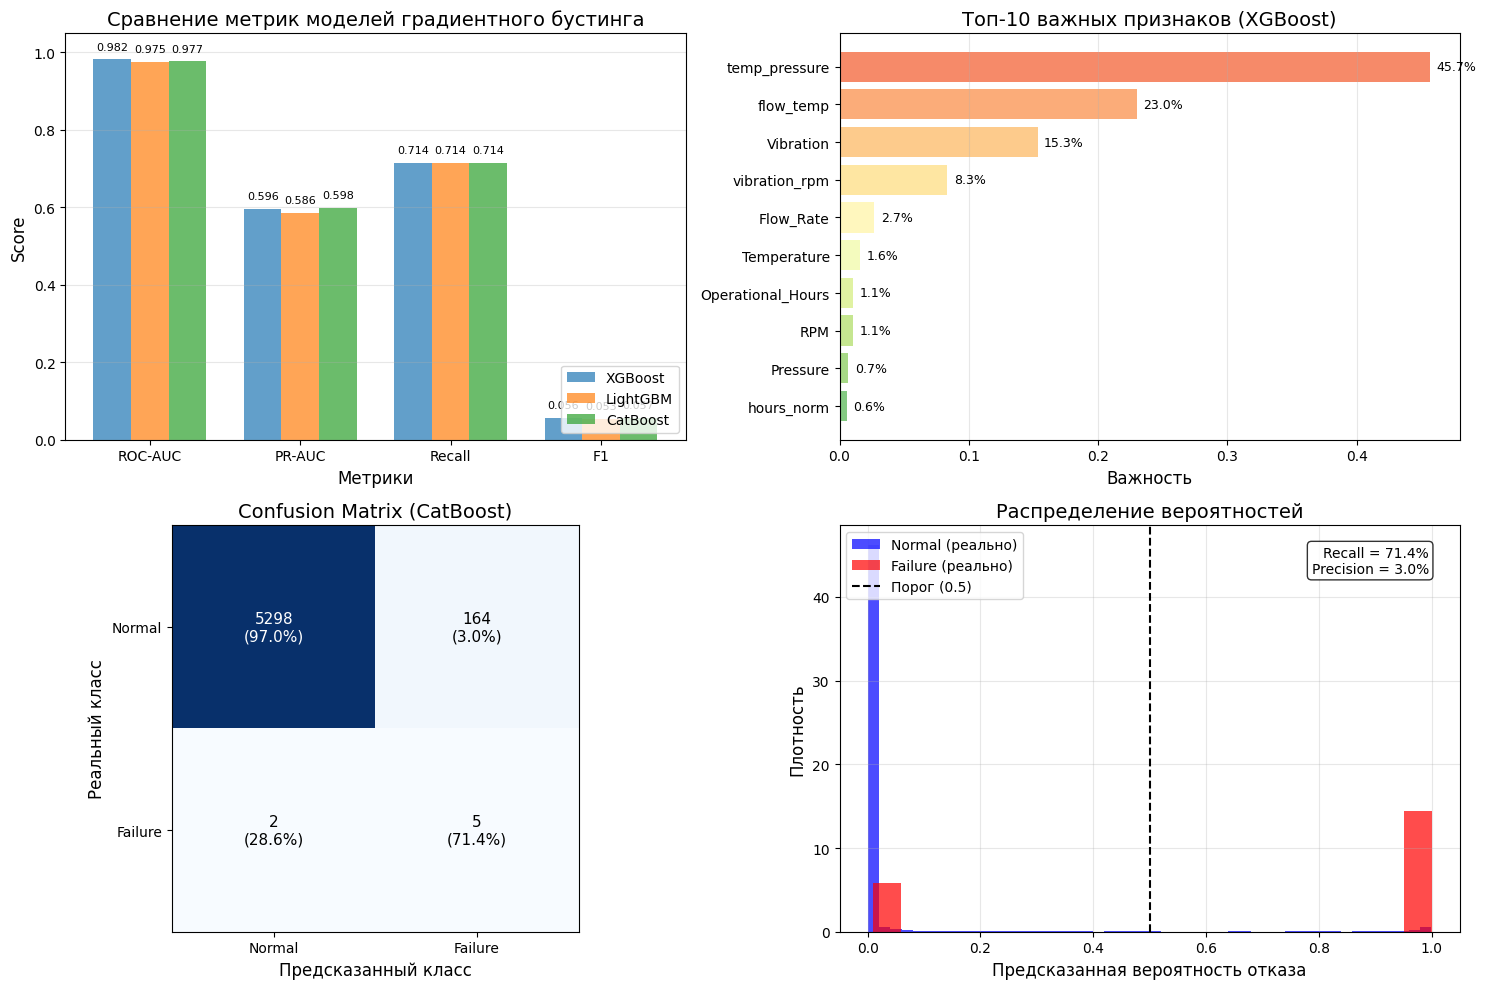

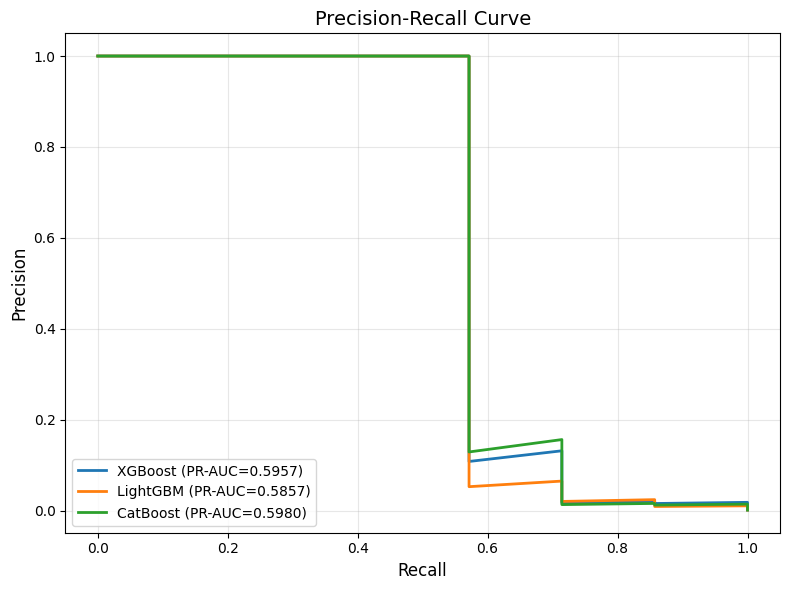

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_names = ['ROC-AUC', 'PR-AUC', 'Recall', 'F1']
xgb_metrics = [roc_auc_xgb, pr_auc_xgb, recall_xgb, f1_xgb]
lgb_metrics = [roc_auc_lgb, pr_auc_lgb, recall_lgb, f1_lgb]
cat_metrics = [roc_auc_cat, pr_auc_cat, recall_cat, f1_cat]

x = np.arange(len(metrics_names))
width = 0.25

bars1 = axes[0, 0].bar(x - width, xgb_metrics, width, label='XGBoost', alpha=0.7, color='#1f77b4')
bars2 = axes[0, 0].bar(x, lgb_metrics, width, label='LightGBM', alpha=0.7, color='#ff7f0e')
bars3 = axes[0, 0].bar(x + width, cat_metrics, width, label='CatBoost', alpha=0.7, color='#2ca02c')

axes[0, 0].set_xlabel('Метрики', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Сравнение метрик моделей градиентного бустинга', fontsize=14)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3, axis='y')

for i in range(len(metrics_names)):
    axes[0, 0].text(x[i] - width, xgb_metrics[i] + 0.02, f'{xgb_metrics[i]:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0, 0].text(x[i], lgb_metrics[i] + 0.02, f'{lgb_metrics[i]:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0, 0].text(x[i] + width, cat_metrics[i] + 0.02, f'{cat_metrics[i]:.3f}', ha='center', va='bottom', fontsize=8)

top_features = feature_importance.head(10).copy()
top_features['feature_str'] = top_features['feature'].astype(str)
top_features = top_features.sort_values('importance', ascending=True)

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_features)))

bars = axes[0, 1].barh(top_features['feature_str'], top_features['importance'], color=colors, alpha=0.8)
axes[0, 1].set_xlabel('Важность', fontsize=12)
axes[0, 1].set_title('Топ-10 важных признаков (XGBoost)', fontsize=14)
axes[0, 1].grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(top_features.iterrows()):
    axes[0, 1].text(row['importance'] + 0.005, i, f"{row['importance']:.1%}", va='center', fontsize=9)

if best_model_name == 'XGBoost':
    y_pred_class = y_pred_xgb_class
    cm = confusion_matrix(y_test, y_pred_class)
elif best_model_name == 'LightGBM':
    y_pred_class = y_pred_lgb_class
    cm = confusion_matrix(y_test, y_pred_class)
else:
    y_pred_class = y_pred_cat_class
    cm = confusion_matrix(y_test, y_pred_class)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = axes[1, 0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Normal', 'Failure'])
axes[1, 0].set_yticklabels(['Normal', 'Failure'])
axes[1, 0].set_xlabel('Предсказанный класс', fontsize=12)
axes[1, 0].set_ylabel('Реальный класс', fontsize=12)
axes[1, 0].set_title(f'Confusion Matrix ({best_model_name})', fontsize=14)


for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        axes[1, 0].text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                        ha='center', va='center', fontsize=11, color=color)

if best_model_name == 'XGBoost':
    probs = y_pred_xgb
elif best_model_name == 'LightGBM':
    probs = y_pred_lgb
else:
    probs = y_pred_cat

axes[1, 1].hist(probs[y_test == 0], bins=50, alpha=0.7, label='Normal (реально)', density=True, color='blue')
axes[1, 1].hist(probs[y_test == 1], bins=20, alpha=0.7, label='Failure (реально)', density=True, color='red')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Порог (0.5)')


tp = cm[1, 1] if cm.shape == (2, 2) else 0
fn = cm[1, 0] if cm.shape == (2, 2) else 0
fp = cm[0, 1] if cm.shape == (2, 2) else 0
recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0

axes[1, 1].text(0.95, 0.95, f'Recall = {recall_val:.1%}\nPrecision = {precision_val:.1%}',
                transform=axes[1, 1].transAxes, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=10)

axes[1, 1].set_xlabel('Предсказанная вероятность отказа', fontsize=12)
axes[1, 1].set_ylabel('Плотность', fontsize=12)
axes[1, 1].set_title('Распределение вероятностей', fontsize=14)
axes[1, 1].legend(loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))

for name, probs, color in [('XGBoost', y_pred_xgb, '#1f77b4'),
                            ('LightGBM', y_pred_lgb, '#ff7f0e'),
                            ('CatBoost', y_pred_cat, '#2ca02c')]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    plt.plot(recall, precision, linewidth=2, color=color, label=f'{name} (PR-AUC={pr_auc:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Подбор параметров

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

base_params = {
    'random_state': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'scale_pos_weight': scale_pos_weight
}

results = []

for n_est in [200, 300]:
    for depth in [3, 4, 5]:
        for lr in [0.05, 0.07]:
            for ss in [0.8]:
                for cs in [0.8]:

                    params = base_params.copy()
                    params['n_estimators'] = n_est
                    params['max_depth'] = depth
                    params['learning_rate'] = lr
                    params['subsample'] = ss
                    params['colsample_bytree'] = cs

                    model = xgb.XGBClassifier(**params)
                    model.fit(X_train, y_train)

                    y_pred = model.predict_proba(X_test)[:, 1]
                    pr_auc = average_precision_score(y_test, y_pred)

                    results.append({
                        'n_estimators': n_est,
                        'max_depth': depth,
                        'learning_rate': lr,
                        'subsample': ss,
                        'colsample_bytree': cs,
                        'PR-AUC': pr_auc
                    })

                    print(f"depth={depth}, lr={lr}, n_est={n_est} -> PR-AUC={pr_auc:.4f}")


results_df = pd.DataFrame(results)
best_idx = results_df['PR-AUC'].idxmax()
best_params = results_df.loc[best_idx]

print("---------")
print("Лучшая модель")
print("---------")
print(f"n_estimators: {int(best_params['n_estimators'])}")
print(f"max_depth: {int(best_params['max_depth'])}")
print(f"learning_rate: {best_params['learning_rate']:.3f}")
print(f"subsample: {best_params['subsample']:.1f}")
print(f"colsample_bytree: {best_params['colsample_bytree']:.1f}")
print(f"PR-AUC: {best_params['PR-AUC']:.4f}")

depth=3, lr=0.05, n_est=200 -> PR-AUC=0.5941
depth=3, lr=0.07, n_est=200 -> PR-AUC=0.5950
depth=4, lr=0.05, n_est=200 -> PR-AUC=0.5957
depth=4, lr=0.07, n_est=200 -> PR-AUC=0.5964
depth=5, lr=0.05, n_est=200 -> PR-AUC=0.5673
depth=5, lr=0.07, n_est=200 -> PR-AUC=0.6558
depth=3, lr=0.05, n_est=300 -> PR-AUC=0.6060
depth=3, lr=0.07, n_est=300 -> PR-AUC=0.6012
depth=4, lr=0.05, n_est=300 -> PR-AUC=0.6022
depth=4, lr=0.07, n_est=300 -> PR-AUC=0.5999
depth=5, lr=0.05, n_est=300 -> PR-AUC=0.6313
depth=5, lr=0.07, n_est=300 -> PR-AUC=0.6655
---------
Лучшая модель
---------
n_estimators: 300
max_depth: 5
learning_rate: 0.070
subsample: 0.8
colsample_bytree: 0.8
PR-AUC: 0.6655


In [ ]:
best_xgb = xgb.XGBClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

best_xgb.fit(X_train, y_train)

y_pred_best = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best_class = best_xgb.predict(X_test)

roc_auc_best = roc_auc_score(y_test, y_pred_best)
pr_auc_best = average_precision_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best_class, zero_division=0)
recall_best = recall_score(y_test, y_pred_best_class, zero_division=0)
f1_best = f1_score(y_test, y_pred_best_class, zero_division=0)

print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"PR-AUC: {pr_auc_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")


print("---------")

comparison = pd.DataFrame([
    {'Модель': 'Baseline (depth=4, lr=0.05, n_est=200)', 'PR-AUC': pr_auc_xgb, 'Recall': recall_xgb},
    {'Модель': f'Optimized (depth={int(best_params["max_depth"])}, lr={best_params["learning_rate"]:.2f}, n_est={int(best_params["n_estimators"])})',
     'PR-AUC': pr_auc_best, 'Recall': recall_best}
])

print(comparison.round(4).to_string(index=False))
print("---------")
print(f"Улучшение PR-AUC: {(pr_auc_best - pr_auc_xgb):.4f} ({(pr_auc_best - pr_auc_xgb)/pr_auc_xgb*100:.1f}%)")

ROC-AUC: 0.9774
PR-AUC: 0.6655
Precision: 0.0360
Recall: 0.7143
F1-score: 0.0685
---------
                                 Модель  PR-AUC  Recall
 Baseline (depth=4, lr=0.05, n_est=200)  0.5957  0.7143
Optimized (depth=5, lr=0.07, n_est=300)  0.6655  0.7143
---------
Улучшение PR-AUC: 0.0698 (11.7%)


Функции потерь

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import average_precision_score, recall_score
import pandas as pd


print("---------")
print("стандартная")
print("---------")

xgb_default = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_default.fit(X_train, y_train)
y_pred_default = xgb_default.predict_proba(X_test)[:, 1]
pr_auc_default = average_precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default > 0.5)

print(f"PR-AUC: {pr_auc_default:.4f}")
print(f"Recall: {recall_default:.4f}")

print("---------")
print("focal loss")
print("---------")


xgb_focal = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight * 1.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_focal.fit(X_train, y_train)
y_pred_focal = xgb_focal.predict_proba(X_test)[:, 1]
pr_auc_focal = average_precision_score(y_test, y_pred_focal)
recall_focal = recall_score(y_test, y_pred_focal > 0.5)

print(f"PR-AUC: {pr_auc_focal:.4f}")
print(f"Recall: {recall_focal:.4f}")

print("---------")
print("weighted loss")
print("---------")

sample_weights = np.ones(len(y_train))
sample_weights[y_train == 1] = scale_pos_weight * 2

xgb_weighted = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_weighted.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_weighted = xgb_weighted.predict_proba(X_test)[:, 1]
pr_auc_weighted = average_precision_score(y_test, y_pred_weighted)
recall_weighted = recall_score(y_test, y_pred_weighted > 0.5)

print(f"PR-AUC: {pr_auc_weighted:.4f}")
print(f"Recall: {recall_weighted:.4f}")



print("---------")

results = pd.DataFrame({
    'Модель': ['Стандартная', 'Focal Loss', 'Weighted'],
    'PR-AUC': [pr_auc_default, pr_auc_focal, pr_auc_weighted],
    'Recall': [recall_default, recall_focal, recall_weighted]
})

print(results.round(4).to_string(index=False))

best_model_idx = results['PR-AUC'].idxmax()
print(f"Лучшая модель: {results.loc[best_model_idx, 'Модель']}")
print(f" PR-AUC = {results.loc[best_model_idx, 'PR-AUC']:.4f}")
print(f" Recall = {results.loc[best_model_idx, 'Recall']:.4f}")
print("---------")


print("---------")
print("увеличение веса")
print("---------")

weight_values = [2, 5, 10, 20]
for w in weight_values:
    sample_weights_test = np.ones(len(y_train))
    sample_weights_test[y_train == 1] = scale_pos_weight * w

    xgb_test = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.07,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_test.fit(X_train, y_train, sample_weight=sample_weights_test)
    y_pred_test = xgb_test.predict_proba(X_test)[:, 1]
    pr_auc_test = average_precision_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test > 0.5)

    print(f"Вес отказа ×{w}: PR-AUC={pr_auc_test:.4f}, Recall={recall_test:.4f}")

---------
стандартная
---------
PR-AUC: 0.6655
Recall: 0.7143
---------
focal loss
---------
PR-AUC: 0.4783
Recall: 0.7143
---------
weighted loss
---------
PR-AUC: 0.5360
Recall: 0.7143
---------
     Модель  PR-AUC  Recall
Стандартная  0.6655  0.7143
 Focal Loss  0.4783  0.7143
   Weighted  0.5360  0.7143
Лучшая модель: Стандартная
 PR-AUC = 0.6655
 Recall = 0.7143
---------
---------
увеличение веса
---------
Вес отказа ×2: PR-AUC=0.5360, Recall=0.7143
Вес отказа ×5: PR-AUC=0.4027, Recall=0.7143
Вес отказа ×10: PR-AUC=0.5895, Recall=0.7143
Вес отказа ×20: PR-AUC=0.5456, Recall=0.7143


In [ ]:
best_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
best_xgb.fit(X_train, y_train)
y_pred_default = best_xgb.predict_proba(X_test)[:, 1]
pr_auc_default = average_precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default > 0.5)

In [ ]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for thresh in thresholds:
    y_pred = (y_pred_default >= thresh).astype(int)

    tp = np.sum((y_pred == 1) & (y_test == 1))
    fp = np.sum((y_pred == 1) & (y_test == 0))
    fn = np.sum((y_pred == 0) & (y_test == 1))
    tn = np.sum((y_pred == 0) & (y_test == 0))

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'Порог': thresh,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Recall': recall,
        'Precision': precision,
        'F1': f1
    })

threshold_df = pd.DataFrame(results)

for col in ['Recall', 'Precision', 'F1']:
    threshold_df[col] = threshold_df[col].round(4)


print(threshold_df.to_string(index=False))


best_idx = threshold_df['F1'].idxmax()
best_threshold = threshold_df.loc[best_idx, 'Порог']
best_f1 = threshold_df.loc[best_idx, 'F1']

print("---------")
print(f"Оптимальный порог: {best_threshold}")
print(f"F1 = {best_f1:.4f}")
print(f"Recall = {threshold_df.loc[best_idx, 'Recall']:.4f}")
print(f"Precision = {threshold_df.loc[best_idx, 'Precision']:.4f}")

 Порог  TP  FP  FN   TN  Recall  Precision     F1
   0.1   5 189   2 5273  0.7143     0.0258 0.0498
   0.2   5 168   2 5294  0.7143     0.0289 0.0556
   0.3   5 153   2 5309  0.7143     0.0316 0.0606
   0.4   5 145   2 5317  0.7143     0.0333 0.0637
   0.5   5 134   2 5328  0.7143     0.0360 0.0685
   0.6   5 124   2 5338  0.7143     0.0388 0.0735
   0.7   5 113   2 5349  0.7143     0.0424 0.0800
   0.8   5 108   2 5354  0.7143     0.0442 0.0833
   0.9   5  95   2 5367  0.7143     0.0500 0.0935
---------
Оптимальный порог: 0.9
F1 = 0.0935
Recall = 0.7143
Precision = 0.0500


SMOTE
------
До SMOTE: 24 отказов
После SMOTE: 1450 отказов
PR-AUC: 0.4200
Recall: 0.7143
------
Under-sampling
------
До under-sampling: 14507 норма, 24 отказов
После under-sampling: 240 норма, 24 отказов
PR-AUC: 0.3314
Recall: 1.0000
------
SMOTE + TOMEK
------
PR-AUC: 0.4200
Recall: 0.7143
------
RF
------
PR-AUC: 0.1668
Recall: 1.0000
------
ADASYN
------
PR-AUC: 0.4211
Recall: 0.7143
------
Сравнение
------
         Метод  PR-AUC  Recall
      Baseline  0.5957  0.7143
         SMOTE  0.4200  0.7143
Under-sampling  0.3314  1.0000
   SMOTE+Tomek  0.4200  0.7143
    BalancedRF  0.1668  1.0000
        ADASYN  0.4211  0.7143


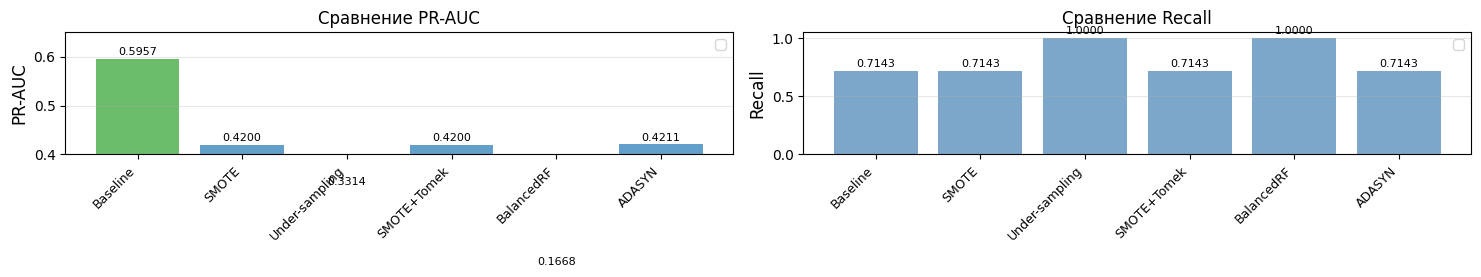

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import average_precision_score, recall_score


print("SMOTE")
print("------")

smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"До SMOTE: {sum(y_train)} отказов")
print(f"После SMOTE: {sum(y_train_smote)} отказов")

xgb_smote = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = xgb_smote.predict_proba(X_test)[:, 1]
pr_auc_smote = average_precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote > 0.5)

print(f"PR-AUC: {pr_auc_smote:.4f}")
print(f"Recall: {recall_smote:.4f}")

print("------")
print("Under-sampling")
print("------")

under = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)

print(f"До under-sampling: {sum(y_train==0)} норма, {sum(y_train)} отказов")
print(f"После under-sampling: {sum(y_train_under==0)} норма, {sum(y_train_under)} отказов")

xgb_under = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_under.fit(X_train_under, y_train_under)
y_pred_under = xgb_under.predict_proba(X_test)[:, 1]
pr_auc_under = average_precision_score(y_test, y_pred_under)
recall_under = recall_score(y_test, y_pred_under > 0.5)

print(f"PR-AUC: {pr_auc_under:.4f}")
print(f"Recall: {recall_under:.4f}")

print("------")
print("SMOTE + TOMEK")
print("------")

smt = SMOTETomek(sampling_strategy=0.1, random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

xgb_smt = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_smt.fit(X_train_smt, y_train_smt)
y_pred_smt = xgb_smt.predict_proba(X_test)[:, 1]
pr_auc_smt = average_precision_score(y_test, y_pred_smt)
recall_smt = recall_score(y_test, y_pred_smt > 0.5)

print(f"PR-AUC: {pr_auc_smt:.4f}")
print(f"Recall: {recall_smt:.4f}")

print("------")
print("RF")
print("------")

brf = BalancedRandomForestClassifier(
    n_estimators=200,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train, y_train)
y_pred_brf = brf.predict_proba(X_test)[:, 1]
pr_auc_brf = average_precision_score(y_test, y_pred_brf)
recall_brf = recall_score(y_test, y_pred_brf > 0.5)

print(f"PR-AUC: {pr_auc_brf:.4f}")
print(f"Recall: {recall_brf:.4f}")

print("------")
print("ADASYN")
print("------")

adasyn = ADASYN(sampling_strategy=0.1, random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

xgb_adasyn = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_adasyn.fit(X_train_adasyn, y_train_adasyn)
y_pred_adasyn = xgb_adasyn.predict_proba(X_test)[:, 1]
pr_auc_adasyn = average_precision_score(y_test, y_pred_adasyn)
recall_adasyn = recall_score(y_test, y_pred_adasyn > 0.5)

print(f"PR-AUC: {pr_auc_adasyn:.4f}")
print(f"Recall: {recall_adasyn:.4f}")


print("------")
print("Сравнение")
print("------")

final_comparison = pd.DataFrame([
    {'Метод':'Baseline', 'PR-AUC': pr_auc_xgb, 'Recall': recall_xgb},
    {'Метод':'SMOTE', 'PR-AUC': pr_auc_smote, 'Recall': recall_smote},
    {'Метод': 'Under-sampling', 'PR-AUC': pr_auc_under, 'Recall': recall_under},
    {'Метод': 'SMOTE+Tomek', 'PR-AUC': pr_auc_smt, 'Recall': recall_smt},
    {'Метод': 'BalancedRF', 'PR-AUC': pr_auc_brf, 'Recall': recall_brf},
    {'Метод': 'ADASYN', 'PR-AUC': pr_auc_adasyn, 'Recall': recall_adasyn},
])

print(final_comparison.round(4).to_string(index=False))



fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
methods = final_comparison['Метод'].values
pr_aucs = final_comparison['PR-AUC'].values
colors = ['#1f77b4' if x < 0.59 else '#2ca02c' for x in pr_aucs]
bars = ax1.bar(range(len(methods)), pr_aucs, color=colors, alpha=0.7)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('PR-AUC', fontsize=12)
ax1.set_title('Сравнение PR-AUC', fontsize=12)
ax1.set_ylim(0.4, 0.65)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

for bar, val in zip(bars, pr_aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)


ax2 = axes[1]
recalls = final_comparison['Recall'].values
bars2 = ax2.bar(range(len(methods)), recalls, color='steelblue', alpha=0.7)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Recall', fontsize=12)
ax2.set_title('Сравнение Recall', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

for bar, val in zip(bars2, recalls):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

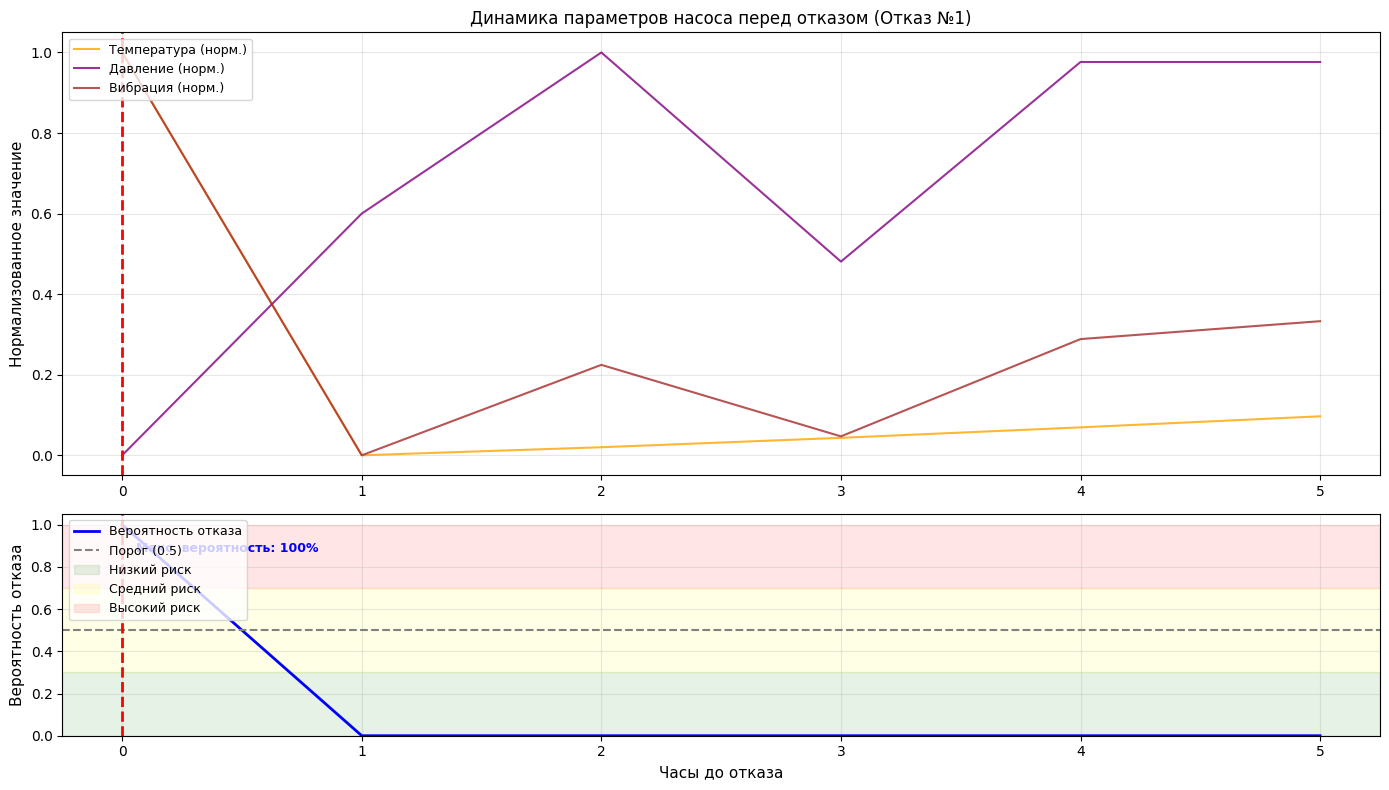

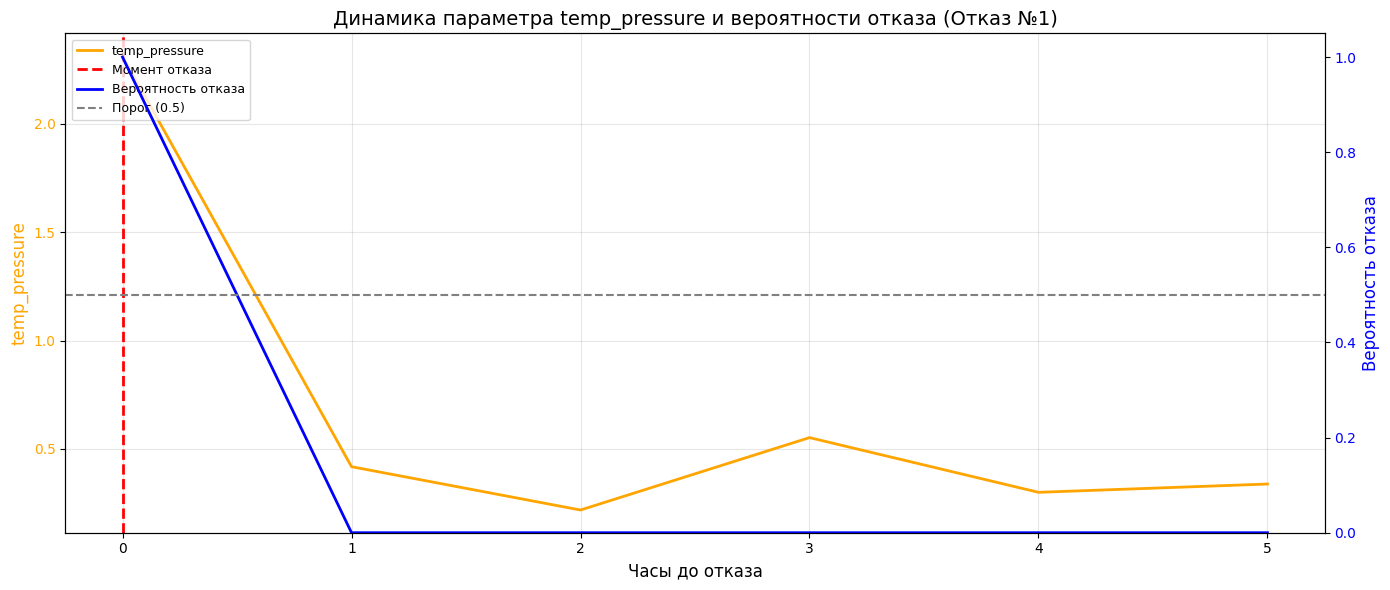

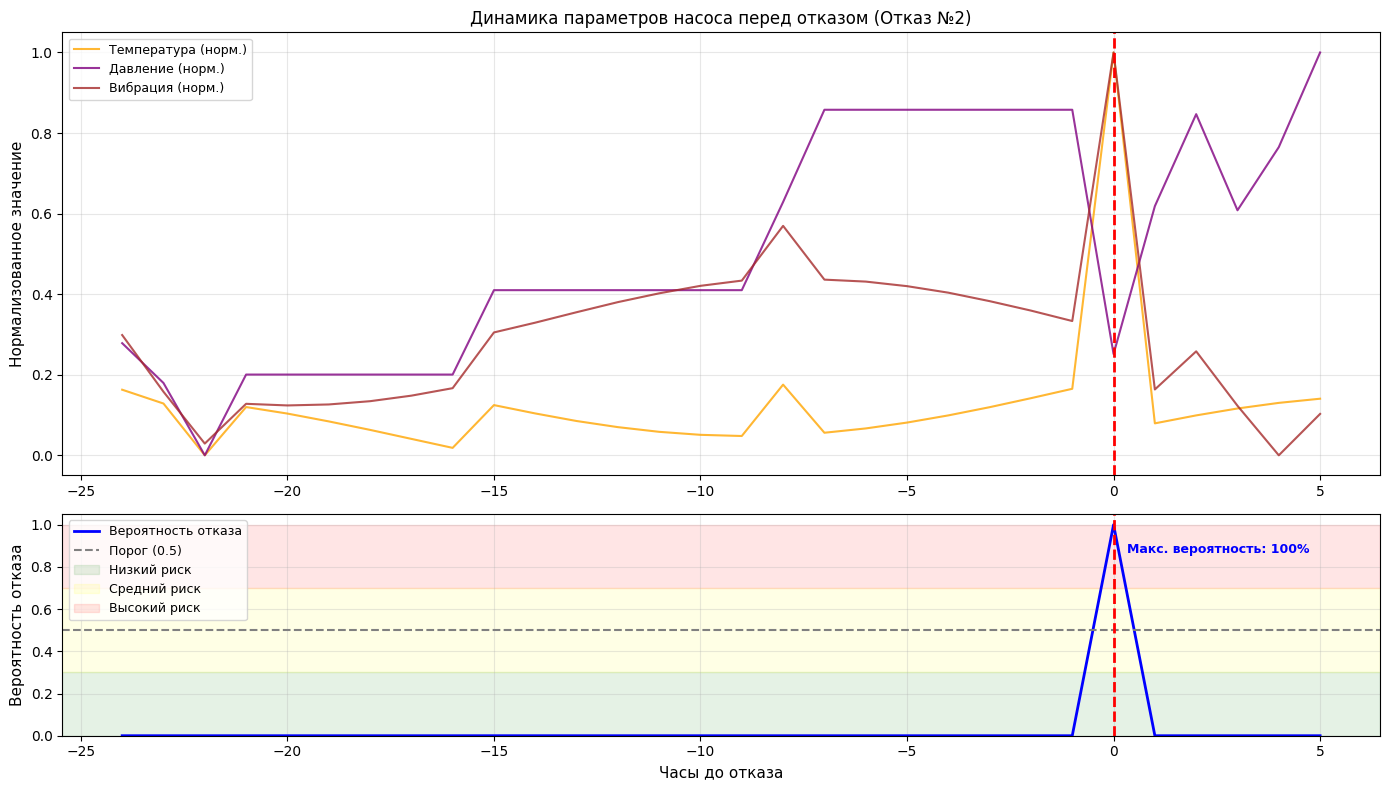

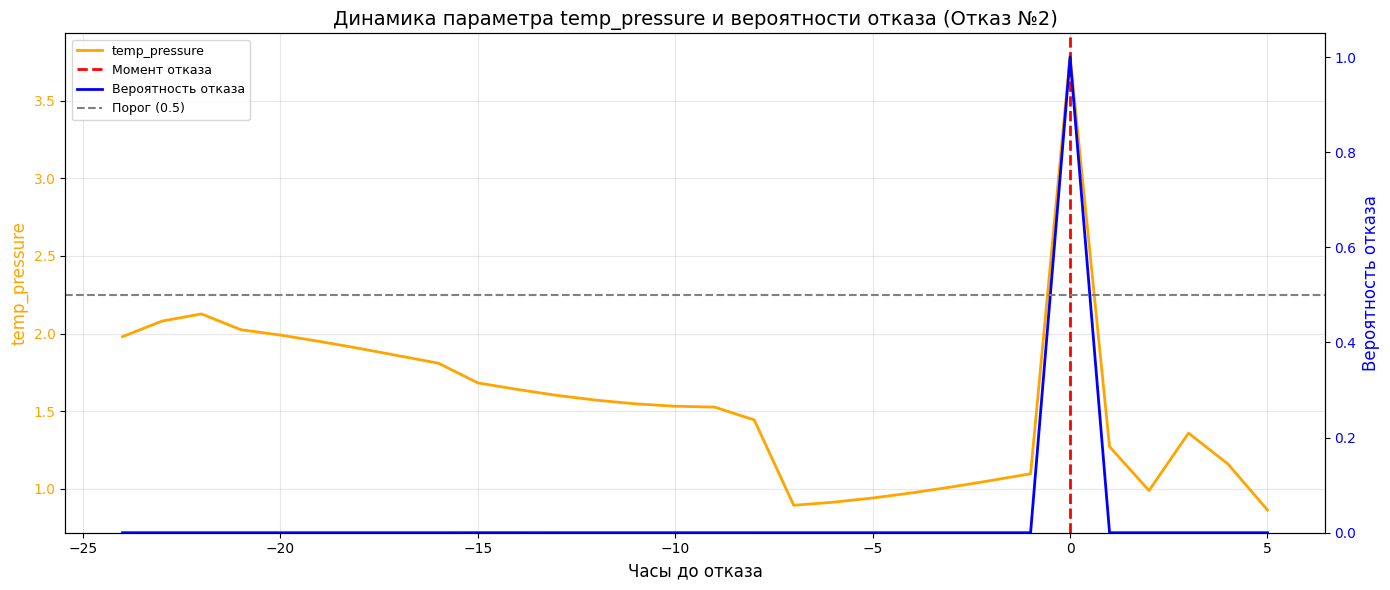

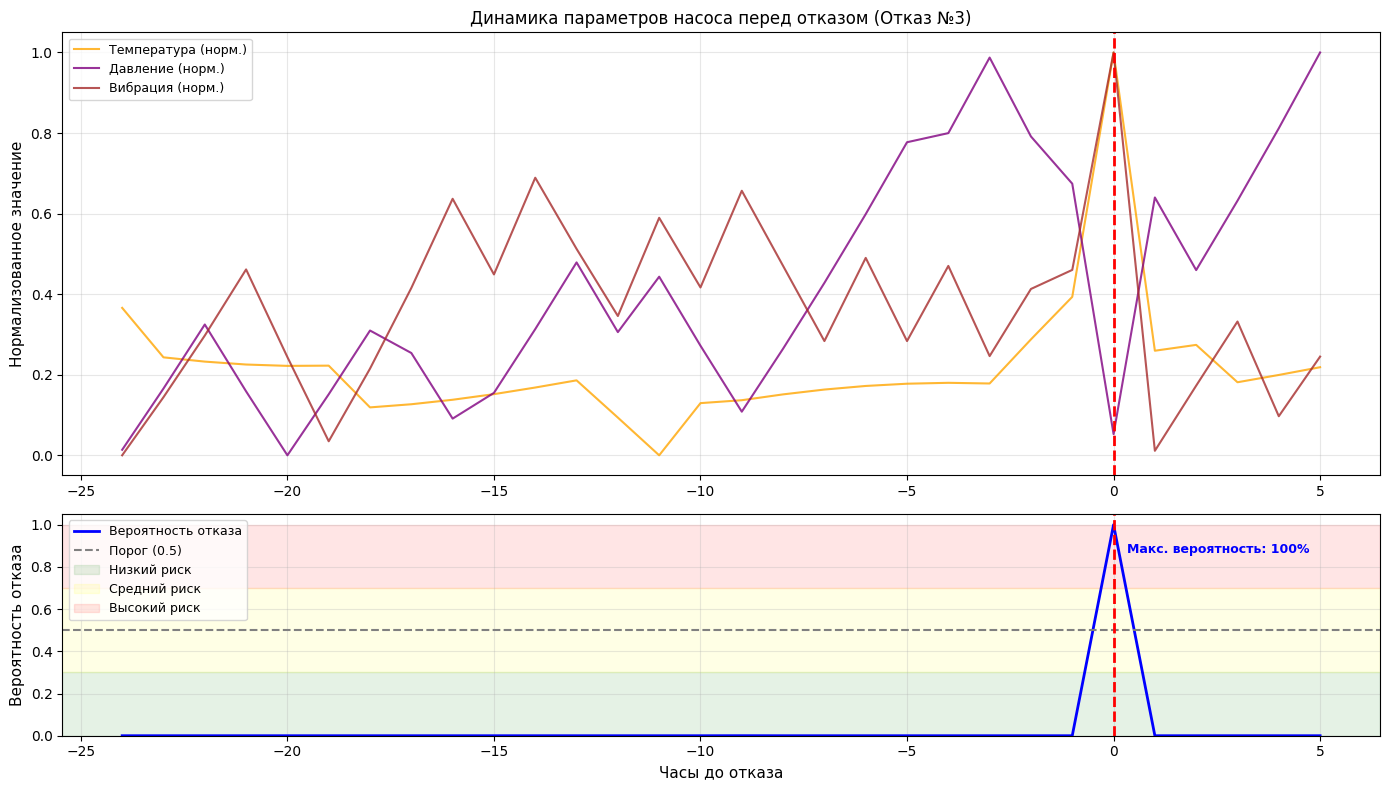

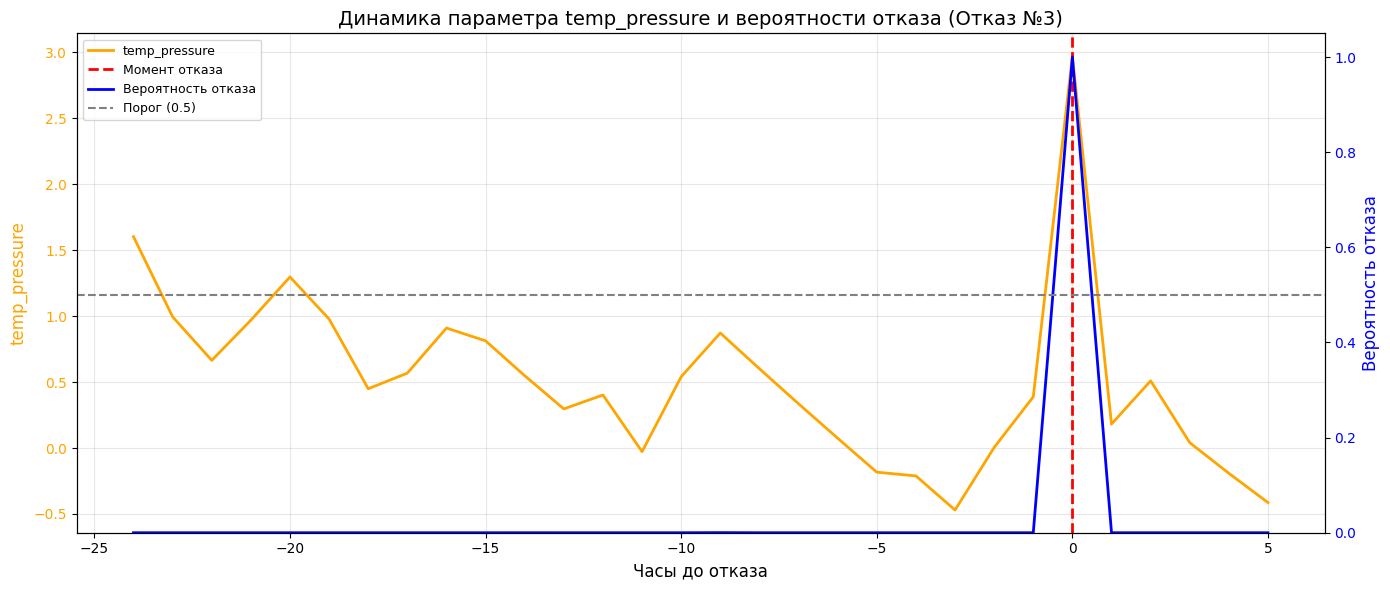

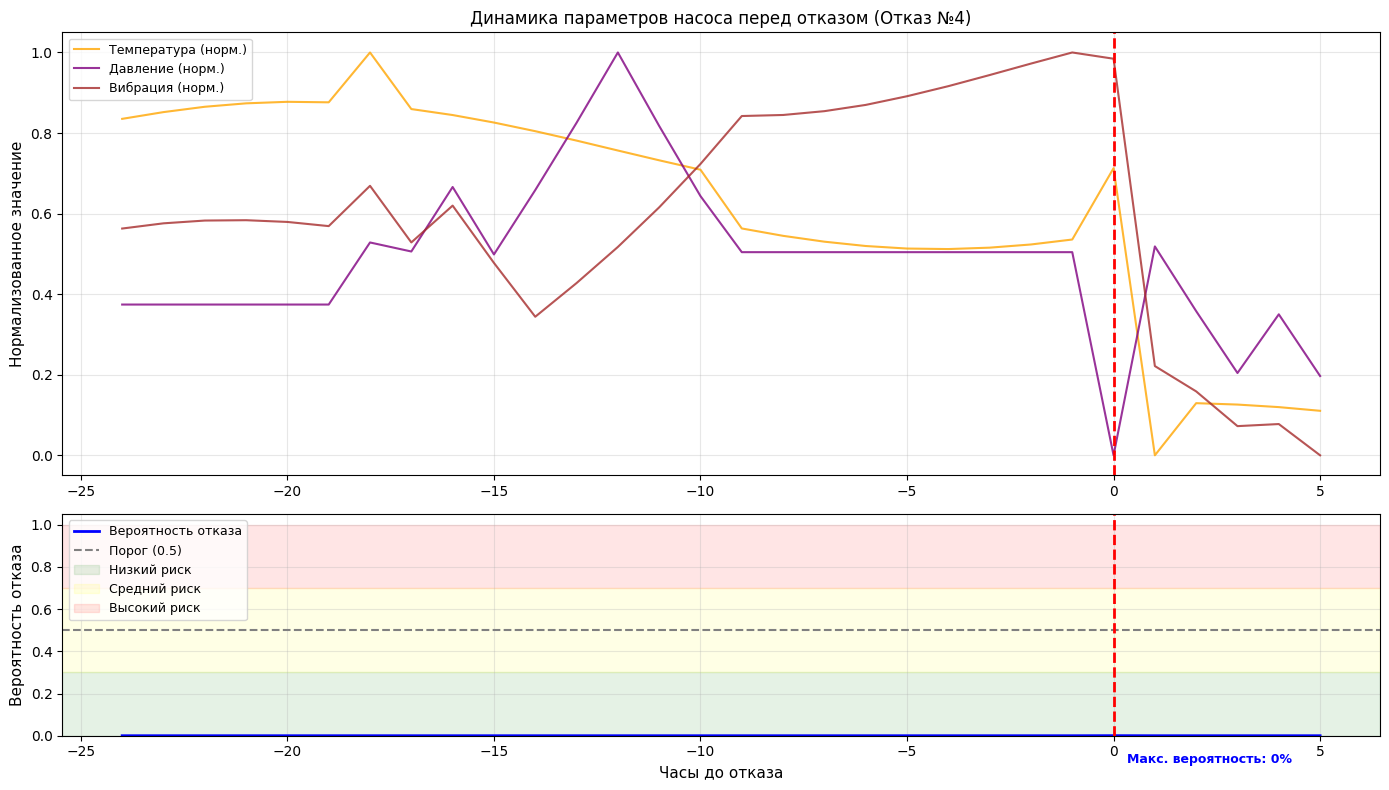

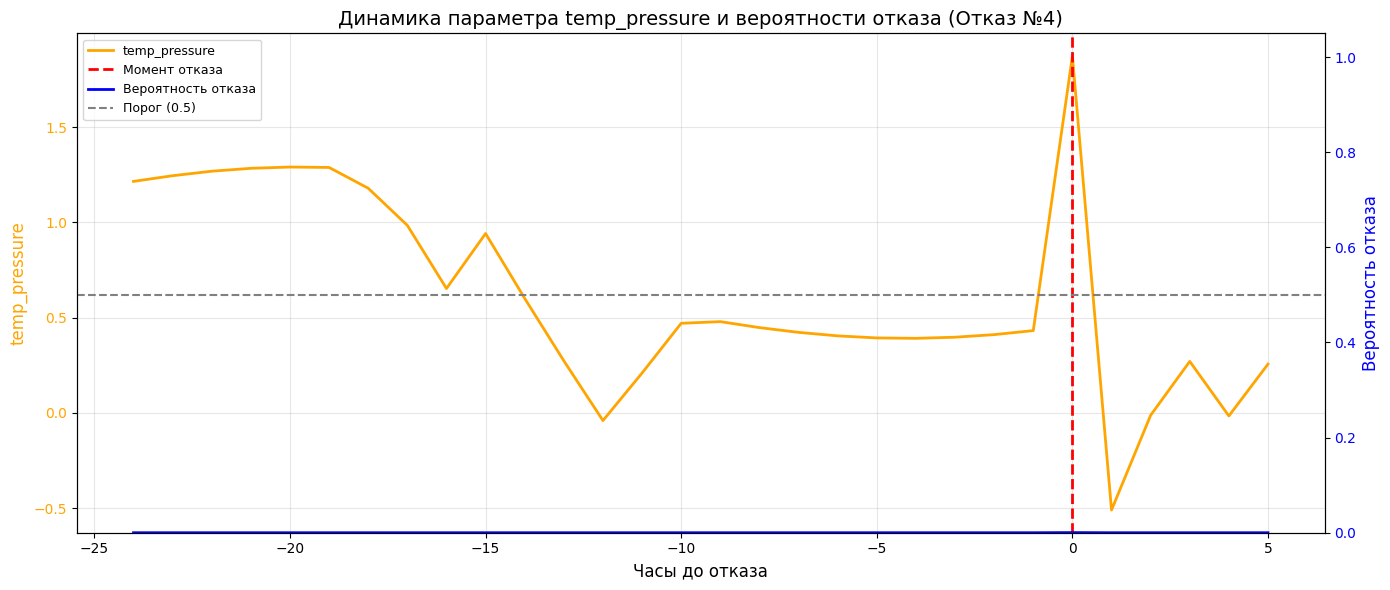

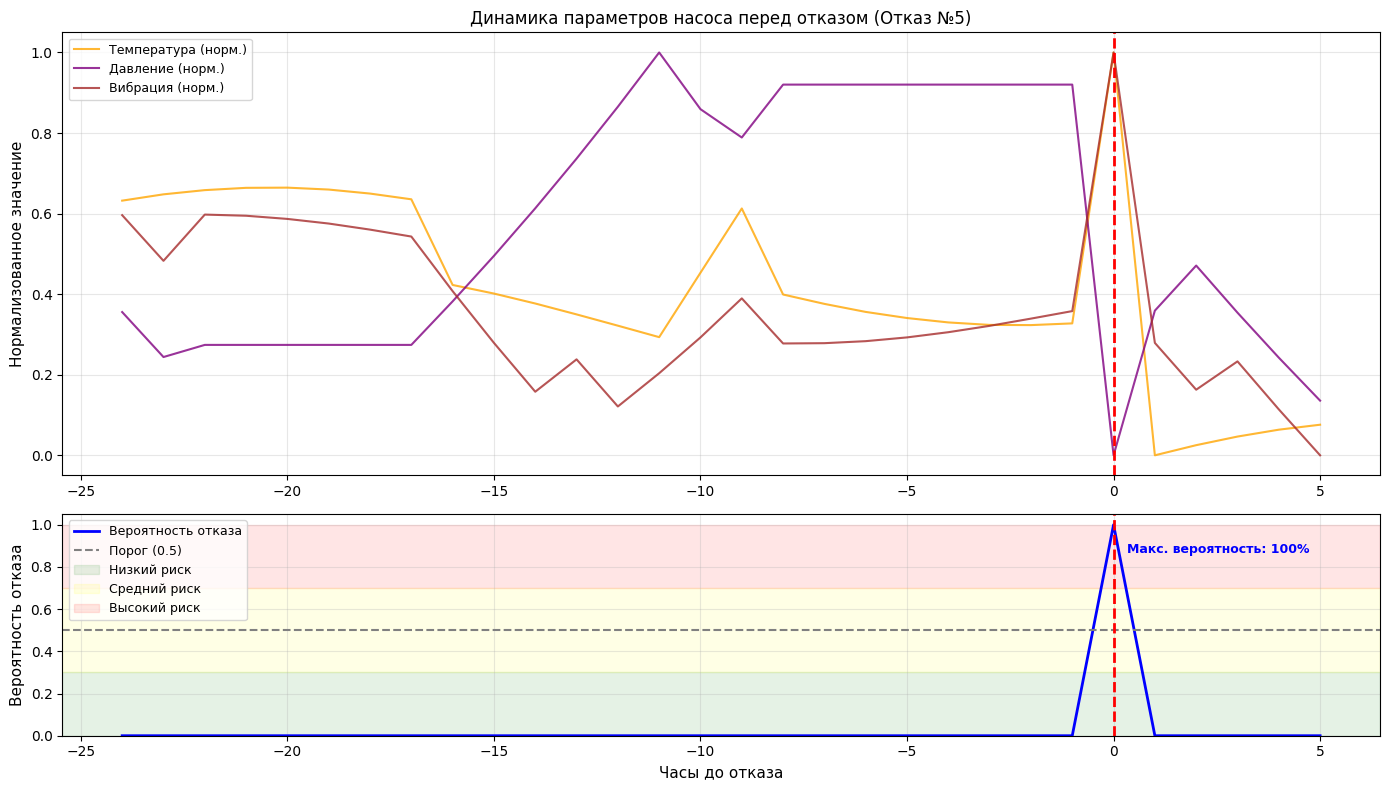

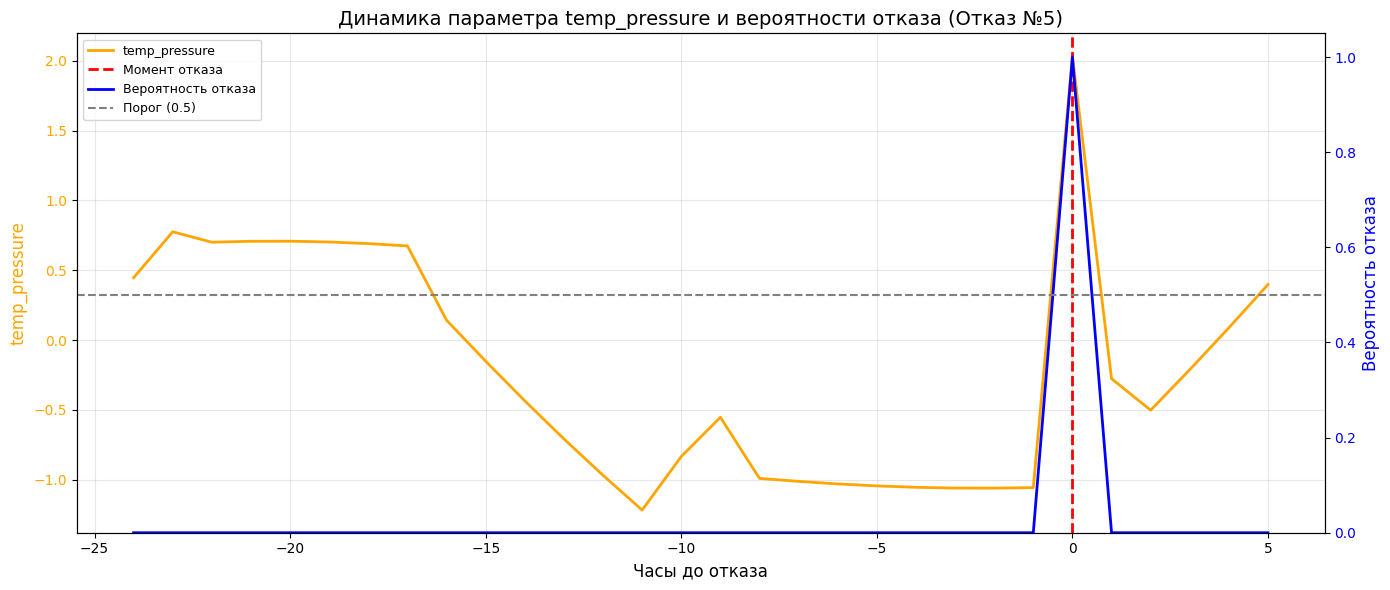

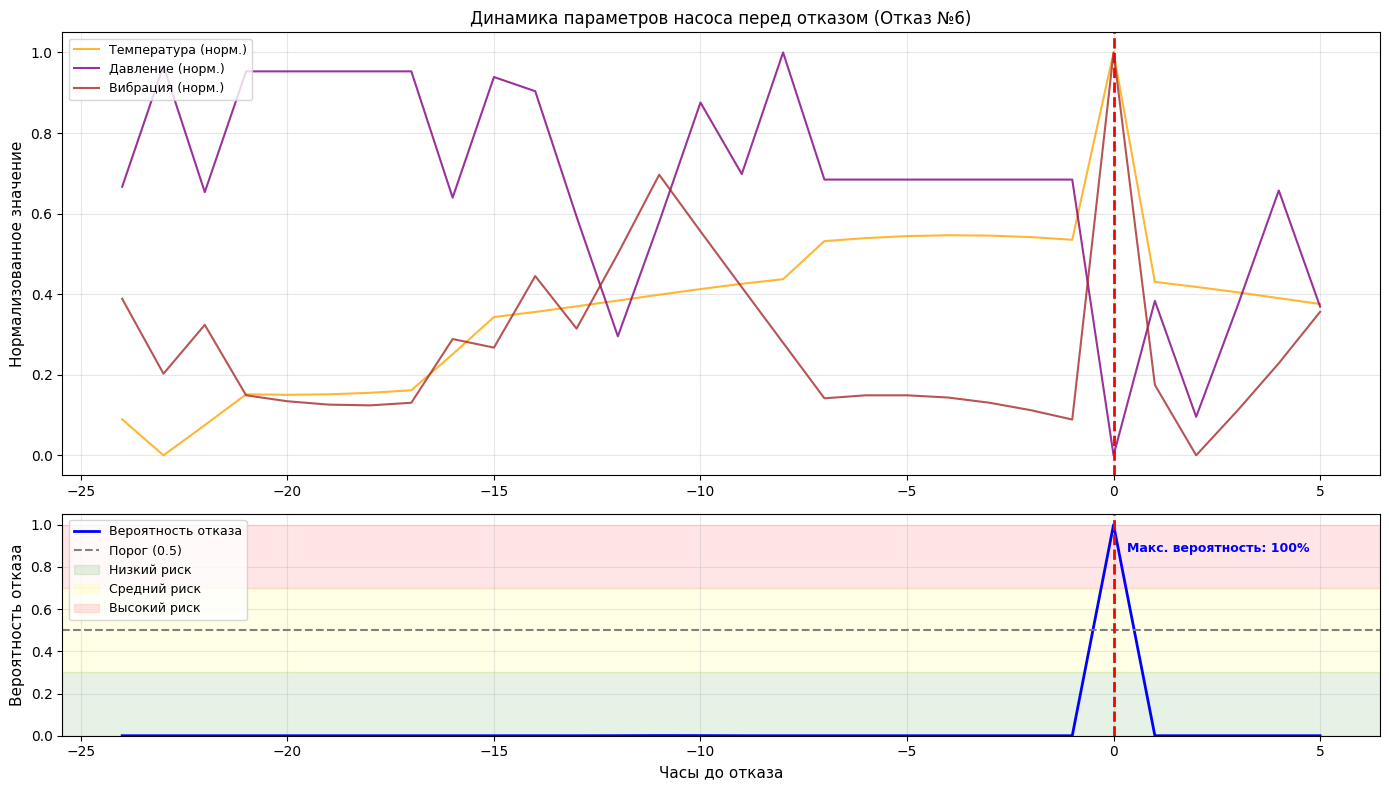

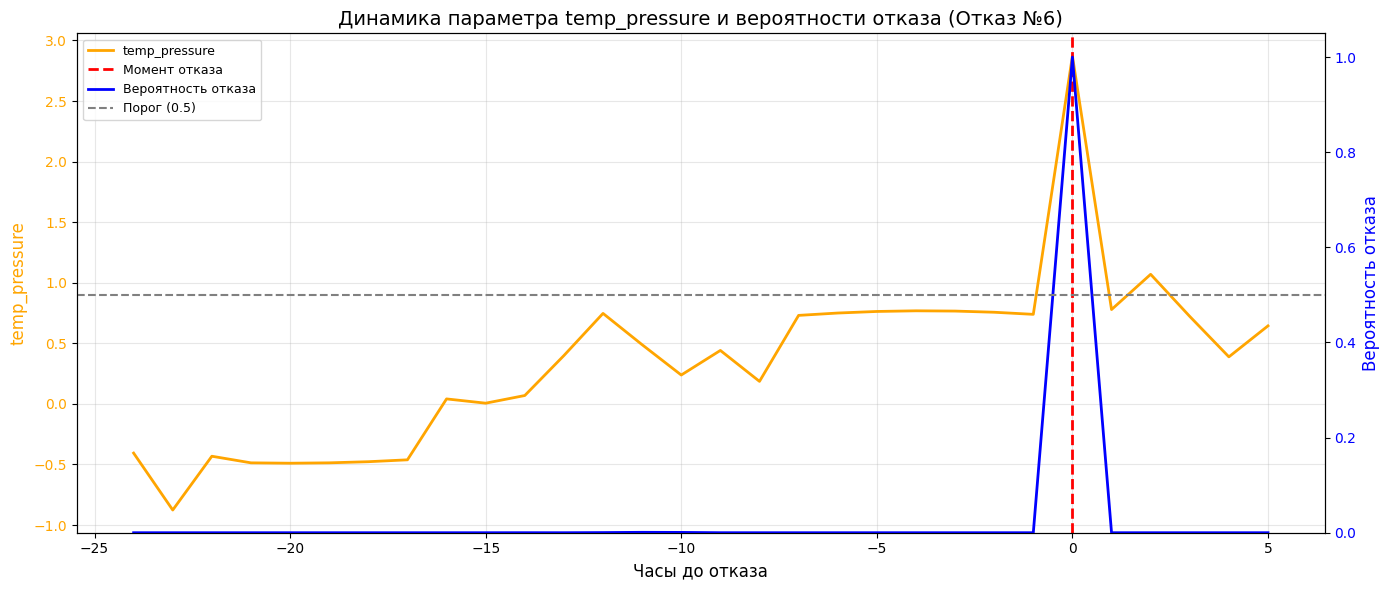

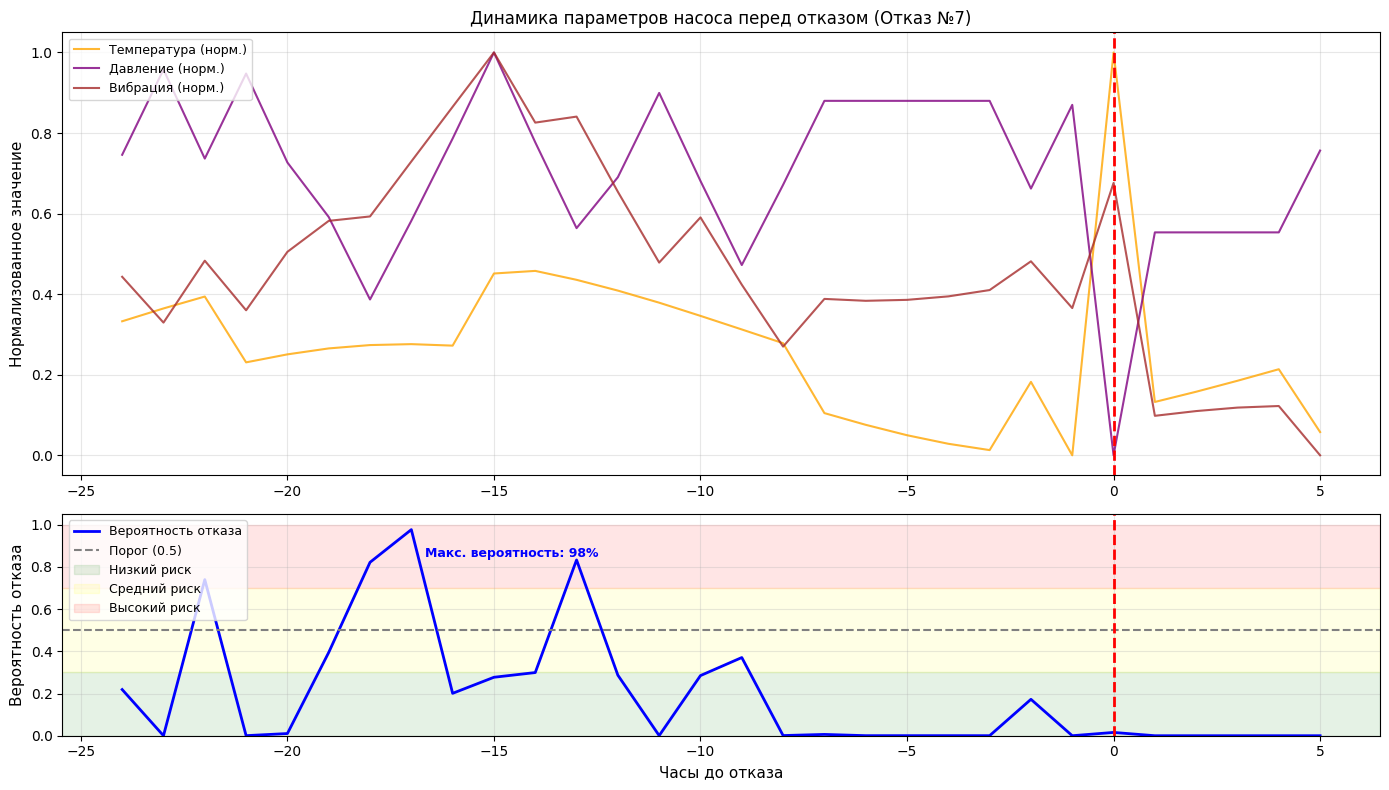

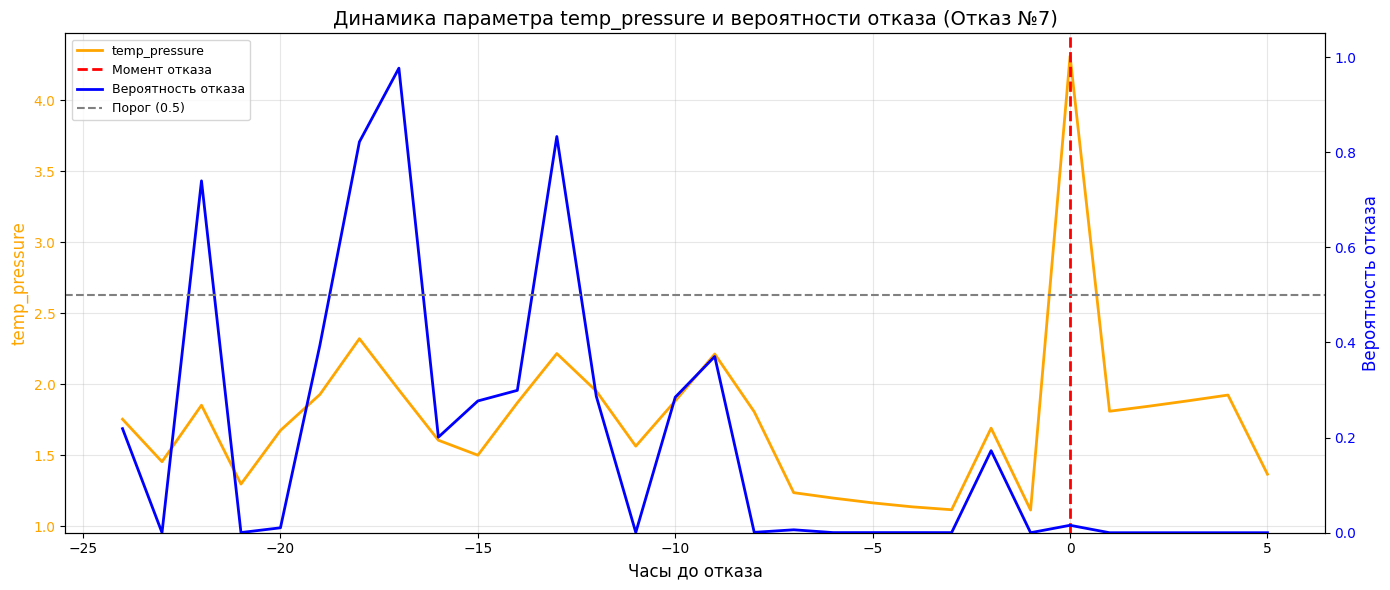

In [ ]:

test_results = pd.DataFrame(X_test, columns=feature_cols)

best_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.07,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

best_xgb.fit(X_train, y_train)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]
model_name = "XGBoost baseline"


if isinstance(y_test, pd.Series):
    test_results['actual_failure'] = y_test.values
else:
    test_results['actual_failure'] = y_test

test_results['predicted_probability'] = y_pred_proba

if 'Operational_Hours' in test_results.columns:
    test_results['time'] = test_results['Operational_Hours']
else:
    test_results['time'] = range(len(test_results))

if 'temp_pressure' not in test_results.columns:
    if 'Temperature' in test_results.columns and 'Pressure' in test_results.columns:
        test_results['temp_pressure'] = test_results['Temperature'] / (test_results['Pressure'] + 1e-10)
    else:
        test_results['temp_pressure'] = 0

if 'flow_temp' not in test_results.columns:
    if 'Flow_Rate' in test_results.columns and 'Temperature' in test_results.columns:
        test_results['flow_temp'] = test_results['Flow_Rate'] / (test_results['Temperature'] + 1e-10)
    else:
        test_results['flow_temp'] = 0

if 'vibration_rpm' not in test_results.columns:
    if 'Vibration' in test_results.columns and 'RPM' in test_results.columns:
        test_results['vibration_rpm'] = test_results['Vibration'] / (test_results['RPM'] + 1e-10)
    else:
        test_results['vibration_rpm'] = 0


WINDOW_BEFORE = 24
WINDOW_AFTER = 6


failure_indices = test_results[test_results['actual_failure'] == 1].index


def normalize(series):
    if len(series) == 0:
        return series
    if series.max() - series.min() > 0:
        return (series - series.min()) / (series.max() - series.min())
    return series - series.min()

for i, failure_idx in enumerate(failure_indices):
    try:
        failure_pos = test_results.index.get_loc(failure_idx)
        window_start = max(0, failure_pos - WINDOW_BEFORE)
        window_end = min(len(test_results), failure_pos + WINDOW_AFTER)
        window_data = test_results.iloc[window_start:window_end].copy()

        before_count = len(window_data[window_data.index < failure_idx])
        after_count = len(window_data[window_data.index >= failure_idx])
        time_hours = list(range(-before_count, after_count))
        window_data['hours_to_failure'] = time_hours[:len(window_data)]


        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                       gridspec_kw={'height_ratios': [1, 0.5]})

        params_to_plot = {
            'Temperature': {'color': 'orange', 'label': 'Температура (норм.)'},
            'Pressure': {'color': 'purple', 'label': 'Давление (норм.)'},
            'Vibration': {'color': 'brown', 'label': 'Вибрация (норм.)'}
        }

        for param, config in params_to_plot.items():
            if param in window_data.columns:
                try:
                    normalized = normalize(window_data[param].values)
                    ax1.plot(window_data['hours_to_failure'], normalized,
                             color=config['color'], linewidth=1.5, alpha=0.8,
                             label=config['label'])
                except:
                    pass

        ax1.set_ylabel('Нормализованное значение', fontsize=11)
        ax1.set_title(f'Динамика параметров насоса перед отказом (Отказ №{i+1})', fontsize=12)
        ax1.legend(loc='upper left', fontsize=9)
        ax1.grid(True, alpha=0.3)
        ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Момент отказа')

        ax2.plot(window_data['hours_to_failure'], window_data['predicted_probability'],
                 'b-', linewidth=2, label='Вероятность отказа')
        ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Порог (0.5)')
        ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)

        ax2.axhspan(0, 0.3, alpha=0.1, color='green', label='Низкий риск')
        ax2.axhspan(0.3, 0.7, alpha=0.1, color='yellow', label='Средний риск')
        ax2.axhspan(0.7, 1, alpha=0.1, color='red', label='Высокий риск')

        ax2.set_xlabel('Часы до отказа', fontsize=11)
        ax2.set_ylabel('Вероятность отказа', fontsize=11)
        ax2.legend(loc='upper left', fontsize=9)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 1.05)

        # Аннотация с максимальной вероятностью
        if len(window_data['predicted_probability']) > 0:
            max_prob = window_data['predicted_probability'].max()
            max_prob_idx = window_data['predicted_probability'].idxmax()
            if max_prob_idx in window_data.index:
                max_prob_hour = window_data.loc[max_prob_idx, 'hours_to_failure']
                ax2.annotate(f'Макс. вероятность: {max_prob:.0%}',
                             xy=(max_prob_hour, max_prob),
                             xytext=(10, -20), textcoords='offset points',
                             fontsize=9, color='blue', fontweight='bold')

        plt.tight_layout()
        plt.savefig(f'failure_{i+1}_with_params.png', dpi=150)
        plt.show()


        fig, ax1 = plt.subplots(figsize=(14, 6))
        param_to_show = 'temp_pressure'
        if param_to_show in window_data.columns:
            ax1.plot(window_data['hours_to_failure'], window_data[param_to_show],
                     color='orange', linewidth=2, label=param_to_show)
        ax1.set_xlabel('Часы до отказа', fontsize=12)
        ax1.set_ylabel(param_to_show, color='orange', fontsize=12)
        ax1.tick_params(axis='y', labelcolor='orange')
        ax1.grid(True, alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(window_data['hours_to_failure'], window_data['predicted_probability'],
                 'b-', linewidth=2, label='Вероятность отказа')
        ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Порог (0.5)')
        ax2.set_ylabel('Вероятность отказа', color='blue', fontsize=12)
        ax2.tick_params(axis='y', labelcolor='blue')
        ax2.set_ylim(0, 1.05)

        ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Момент отказа')
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

        plt.title(f'Динамика параметра {param_to_show} и вероятности отказа (Отказ №{i+1})', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'failure_{i+1}_dual_axis.png', dpi=150)
        plt.show()

    except Exception as e:
        print(f"Ошибка")
        continue